# plots for the data paper

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.cm as cm
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

In [20]:
#try new dist from shore code 
from shapely.geometry import Point
def add_distance_to_shore(df, lat_col='lat', lon_col='lon'):
    """
    Takes a dataframe with latitude and longitude columns and adds a new 
    column representing the distance to the closest shore in kilometers.
    """
   
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),crs="EPSG:4326")
    land = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\ne_110m_admin_0_countries\ne_110m_admin_0_countries.shp')
    if land.crs is None:
        print("No CRS found on the shapefile. Assigning standard EPSG:4326...")
        land.set_crs("EPSG:4326", inplace=True)
        
    gdf_metric = gdf.to_crs("EPSG:3857")
    land_metric = land.to_crs("EPSG:3857")
    land_metric['geometry'] = land_metric['geometry'].make_valid()
    unified_land = land_metric.geometry.unary_union
    df['dist_to_shore_km'] = gdf_metric.geometry.distance(unified_land) / 1000
    print("Done!")
    return df

## percentages for each file

11


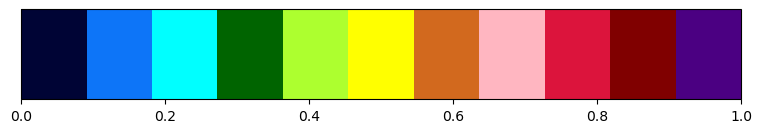

In [3]:
import pylab as pl
import numpy as np
colors = ['xkcd:dark navy','xkcd:deep sky blue','aqua', 'darkgreen','greenyellow','yellow','chocolate','lightpink','crimson','maroon','indigo']
color_bar_custom = mcolors.ListedColormap(colors)
print(len(colors))
a = np.array([[0,1]])
#greenish tan, lichen
pl.figure(figsize=(9, 1.5))
img = pl.imshow(a, cmap=color_bar_custom)
pl.gca().set_visible(False)
cax = pl.axes([0.1, 0.2, 0.8, 0.6])
pl.colorbar(orientation="horizontal", cax=cax)

In [4]:
chl = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_chl.xlsx')

In [6]:
percentages = chl['HPLC'].value_counts(normalize=True) * 100
print(percentages)

HPLC
1    97.303264
0     2.137457
2     0.559279
Name: proportion, dtype: float64


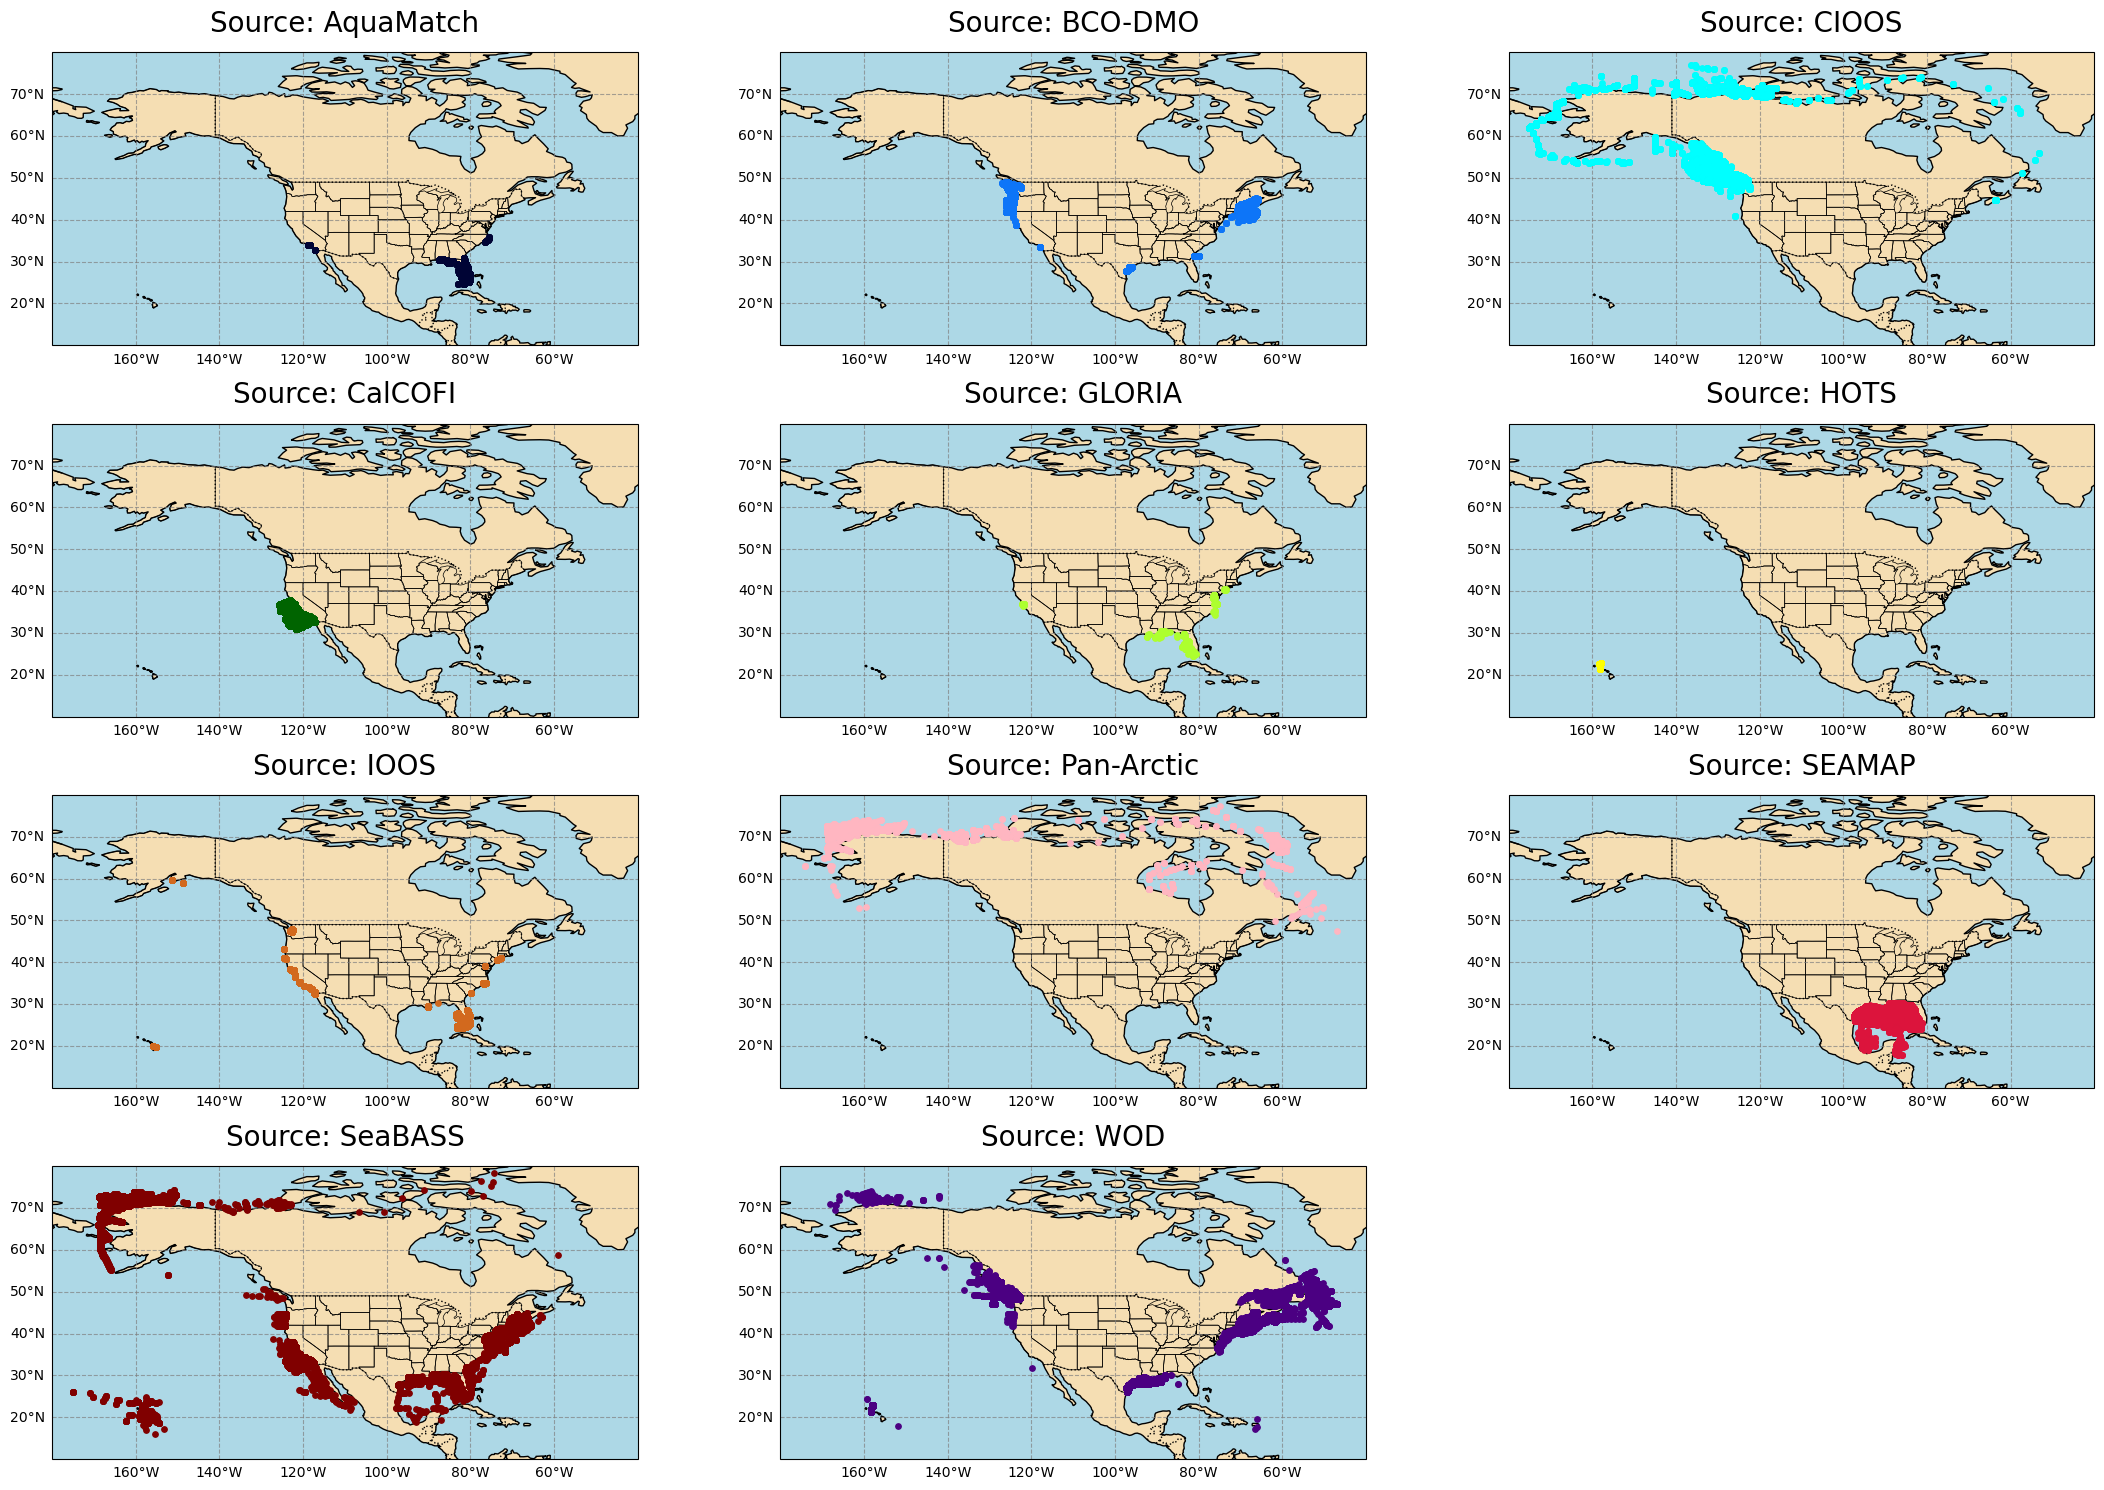

In [127]:
# 1. Get a list of the 7 unique sources from your dataframe
df = chl.copy()
unique_sources = sorted(df['source'].unique())

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(22, 15), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, source in enumerate(unique_sources):
    ax = axes[i]
    subset = df[df['source'] == source]
    
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.LAND, facecolor='wheat')
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1)
    ax.add_feature(cfeature.STATES, linestyle='-', linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), color='gray', linestyle='--', alpha=0.7)
    gl.top_labels = False 
    gl.right_labels = False
    ax.scatter(subset['lon'], subset['lat'], color=colors[i], s=15, transform=ccrs.PlateCarree(), zorder=5)
    ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())
    ax.set_title(f"Source: {source}", fontsize=20, pad=15)

fig.delaxes(axes[11])
plt.tight_layout()


In [7]:
df = chl.copy()
unique_sources = sorted(df['source'].unique())
color_to_source = dict(zip(colors, unique_sources))
color_to_source

{'xkcd:dark navy': 'AquaMatch',
 'xkcd:deep sky blue': 'BCO-DMO',
 'aqua': 'CIOOS',
 'darkgreen': 'CalCOFI',
 'greenyellow': 'GLORIA',
 'yellow': 'HOTS',
 'chocolate': 'IOOS',
 'lightpink': 'Pan-Arctic',
 'crimson': 'SEAMAP',
 'maroon': 'SeaBASS',
 'indigo': 'WOD'}

Text(0.5, 0.98, 'Chlorophyll Data by Source')

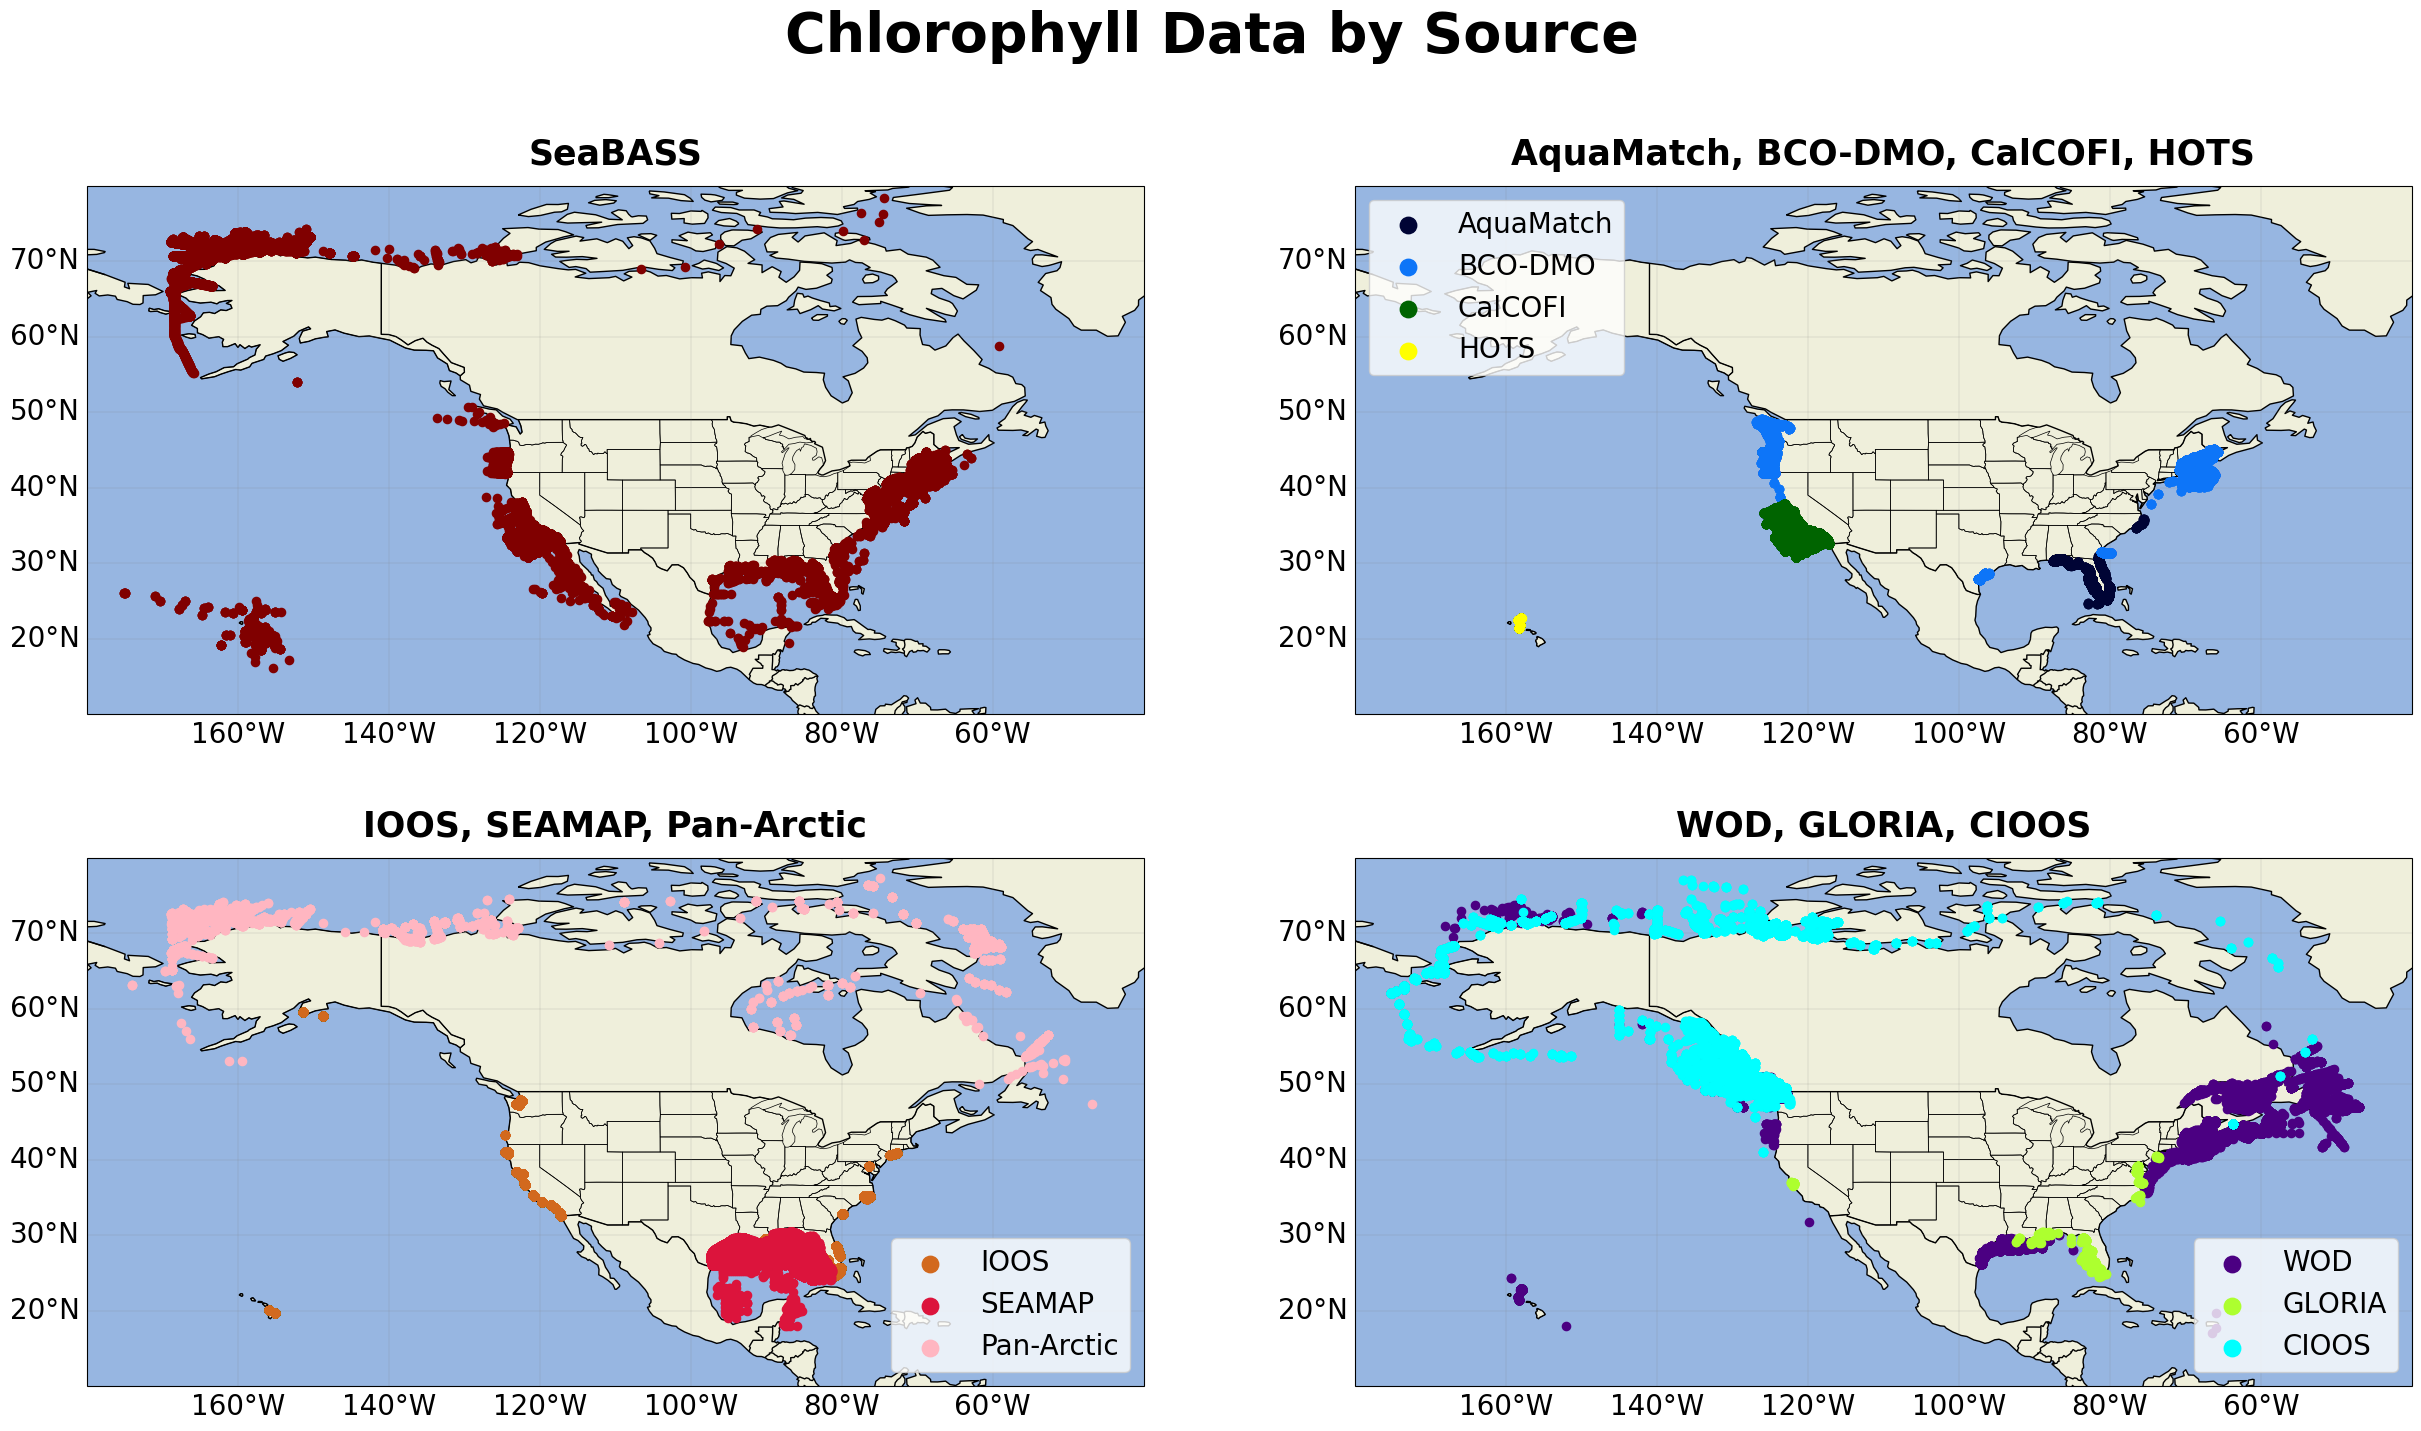

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(30, 16), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()
def format_map(ax, title):
    """Applies standard geographic features and limits to a given axis."""
    ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, linestyle='-', linewidth=0.5)
    gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
    gl.top_labels = False 
    gl.right_labels = False
    gl.xlabel_style = {'size': 20, 'color': 'k'}
    gl.ylabel_style = {'size': 20, 'color': 'k'}
    ax.set_title(title, fontsize=25, pad=15, fontweight="bold")
#SeaBASS
ax0 = axes[0]
src_blue = color_to_source['maroon']
subset_blue = df[df['source'] == src_blue]
ax0.scatter(subset_blue['lon'], subset_blue['lat'], color='maroon', s=35, transform=ccrs.PlateCarree(), zorder=5)
format_map(ax0, f"{src_blue}")

#Combined ones
ax1 = axes[1]
combined_colors = ['xkcd:dark navy', 'xkcd:deep sky blue', 'darkgreen', 'yellow']
for color in combined_colors:
    src = color_to_source[color]
    subset = df[df['source'] == src]
    ax1.scatter(subset['lon'], subset['lat'], color=color, s=35, transform=ccrs.PlateCarree(), zorder=5, label=src)
format_map(ax1, "AquaMatch, BCO-DMO, CalCOFI, HOTS")
ax1.legend(loc='upper left', scatterpoints=1, markerscale=2,fontsize=20) 

#IOOS
ax2 = axes[2]
combined_colors = ['chocolate','crimson', 'lightpink']
for color in combined_colors:
    src = color_to_source[color]
    subset = df[df['source'] == src]
    ax2.scatter(subset['lon'], subset['lat'], color=color, s=35, transform=ccrs.PlateCarree(), zorder=5, label=src)
format_map(ax2, "IOOS, SEAMAP, Pan-Arctic")
ax2.legend(loc='lower right', scatterpoints=1, markerscale=2,fontsize=20) 

#WOD
ax3 = axes[3]
combined_colors = ['indigo','greenyellow', 'aqua']
for color in combined_colors:
    src = color_to_source[color]
    subset = df[df['source'] == src]
    ax3.scatter(subset['lon'], subset['lat'], color=color, s=35, transform=ccrs.PlateCarree(), zorder=5, label=src)
format_map(ax3, "WOD, GLORIA, CIOOS")
ax3.legend(loc='lower right', scatterpoints=1, markerscale=2,fontsize=20) 

fig.suptitle("Chlorophyll Data by Source", fontsize=40, fontweight="bold")

In [4]:
cdom = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_cdom.xlsx')

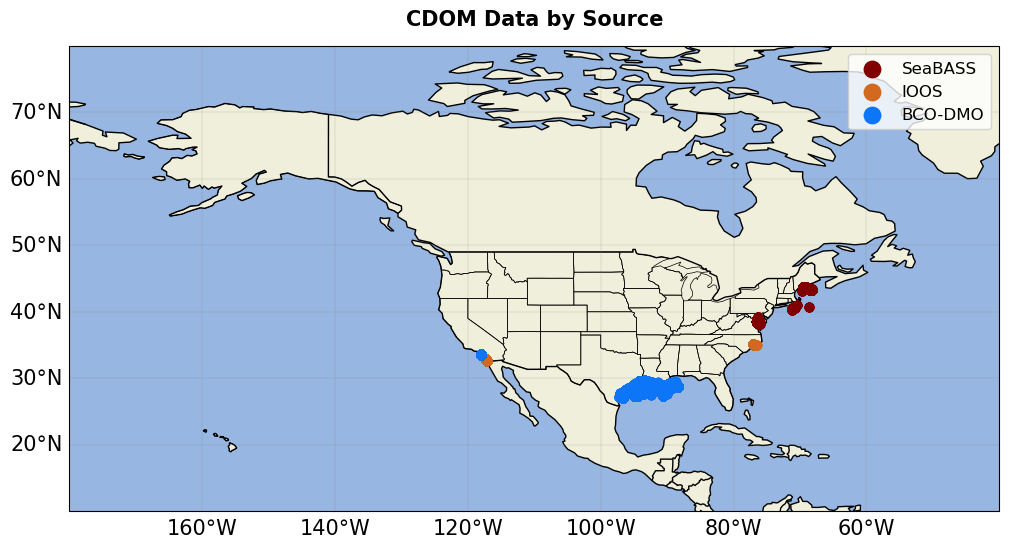

In [10]:
df = cdom.copy()
unique_sources = df['source'].unique()
all_colors = ['maroon', 'chocolate', 'xkcd:deep sky blue']
color_map = dict(zip(unique_sources, all_colors))

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linestyle='-', linewidth=0.5)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.top_labels = False 
gl.right_labels = False
gl.xlabel_style = {'size': 15, 'color': 'k'}
gl.ylabel_style = {'size': 15, 'color': 'k'}
# loop through each source and plot them all on the SAME axis (ax)
for source in unique_sources:
    subset = df[df['source'] == source]
    ax.scatter(subset['lon'],  subset['lat'], color=color_map[source], s=35, transform=ccrs.PlateCarree(), zorder=5, label=source)
ax.set_title("CDOM Data by Source", fontsize=15, pad=15, fontweight="bold")
ax.legend( loc='best', scatterpoints=1, markerscale=2, fontsize=12,)


In [5]:
rrs = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_rrs.xlsx')

In [105]:
total_rows = len(rrs)
percent_data = (rrs.notna().sum() / total_rows) * 100
print(percent_data)

source           100.000000
datetime         100.000000
lon              100.000000
lat              100.000000
depth             94.386107
experiment       100.000000
DOI_url           98.129414
affiliations      97.524224
investigators     37.838861
contact           37.838861
cruise            37.838861
station           37.358939
ID_code          100.000000
rrs              100.000000
wavelength       100.000000
dtype: float64


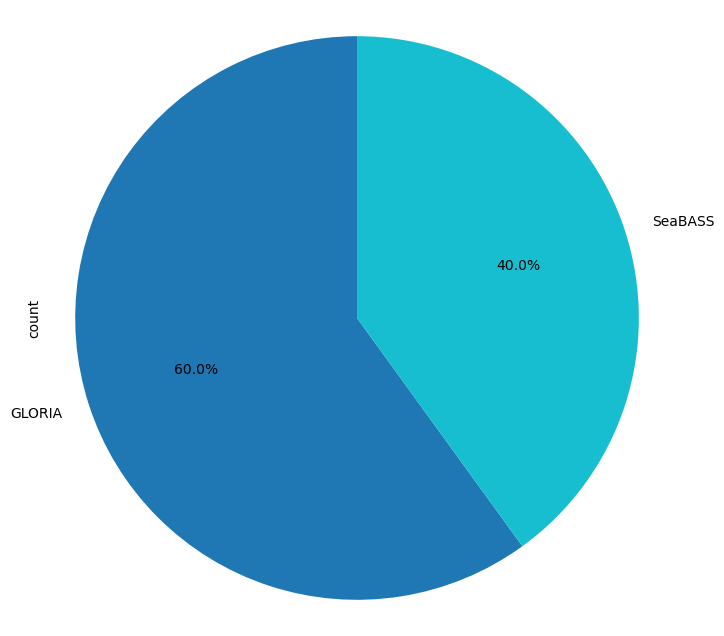

In [21]:
category_counts = rrs['source'].value_counts() 
plt.figure(figsize=(8, 8)) # Optional: set the figure size
category_counts.plot.pie(autopct='%1.1f%%', startangle=90, cmap='tab10')
plt.axis('equal') 
plt.show()

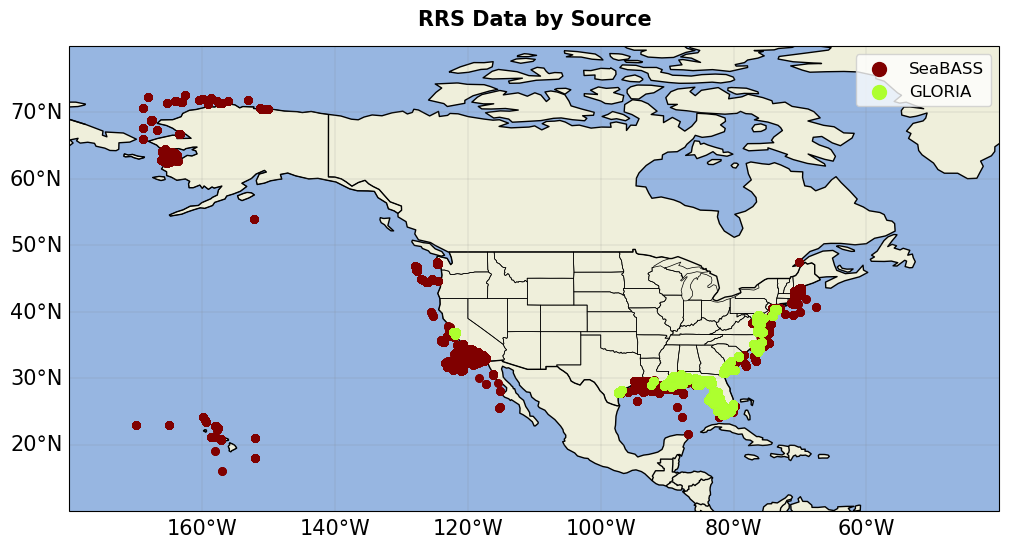

In [22]:
df = rrs.copy()
unique_sources = df['source'].unique()
all_colors = ['maroon', 'greenyellow']
color_map = dict(zip(unique_sources, all_colors))

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linestyle='-', linewidth=0.5)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.top_labels = False 
gl.right_labels = False
gl.xlabel_style = {'size': 15, 'color': 'k'}
gl.ylabel_style = {'size': 15, 'color': 'k'}

# loop through each source and plot them all on the SAME axis (ax)
for source in unique_sources:
    subset = df[df['source'] == source]
    ax.scatter(subset['lon'],  subset['lat'], color=color_map[source], s=25, transform=ccrs.PlateCarree(), zorder=5, label=source)
ax.set_title("RRS Data by Source", fontsize=15, pad=15, fontweight="bold")
ax.legend( loc='best', scatterpoints=1, markerscale=2, fontsize=12)

In [2]:
#filename = r"C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\compiled_chl_variables.csv.gz"
#chl_all = pd.read_csv( filename,  compression='gzip', low_memory=False)
chl_all = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_chl.xlsx')
chl_all['datetime'] = pd.to_datetime(chl_all['datetime'],format='mixed') #ensure datetime is in correct format

In [3]:
df = chl_all.copy()
df['datetime'] = df['datetime'].apply(pd.to_datetime)

# Check our work to make sure we didn't lose anything!
print("Missing datetimes after fix:", df['datetime'].isna().sum())

Missing datetimes after fix: 0


In [4]:
percentages = df['triplicate'].value_counts(normalize=True) * 100
percentages

triplicate
1    99.376493
0     0.623507
Name: proportion, dtype: float64

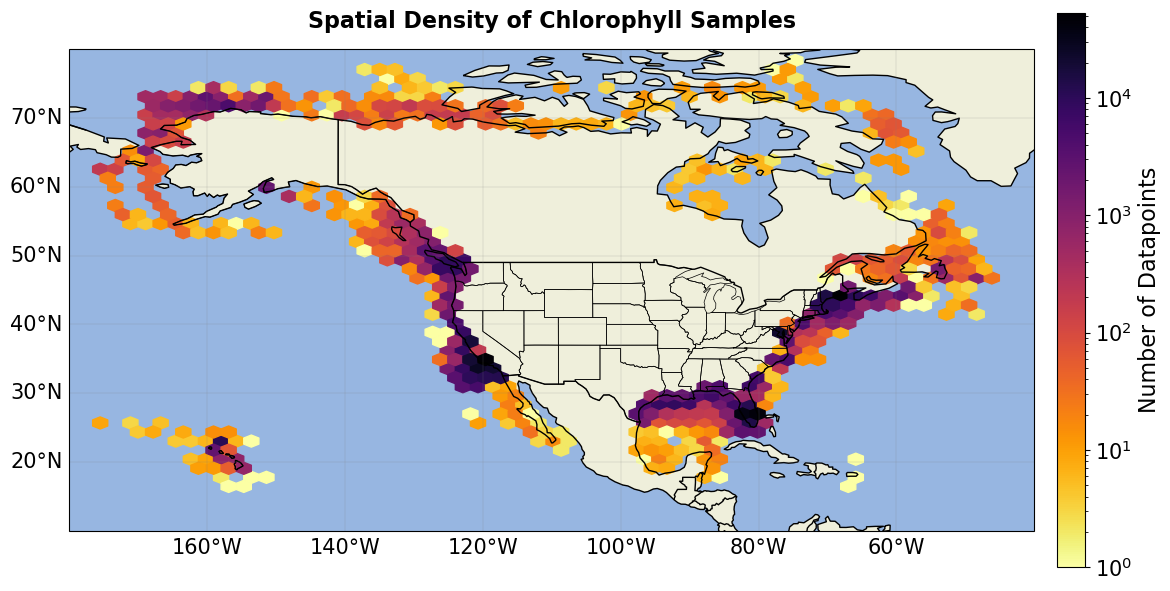

In [5]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 9))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linestyle='-', linewidth=0.5)
#as long as scale is 5 to 1, grid size is normal
hb = ax.hexbin(df.lon, df.lat, gridsize=(150,30), cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) #gridsize used to make sure shapes are normal 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=16)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels(165, 45)
gl.xlabel_style = {'size': 15, 'color': 'k'}
gl.ylabel_style = {'size': 15, 'color': 'k'}
#ax.set_aspect('equal')  # <--- Fixes the elongated shape

ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())
cb.ax.tick_params(labelsize=15) # Adjust '14' to your desired font size

ax.set_title('Spatial Density of Chlorophyll Samples', fontsize=16, pad=15, fontweight='bold')

plt.show()

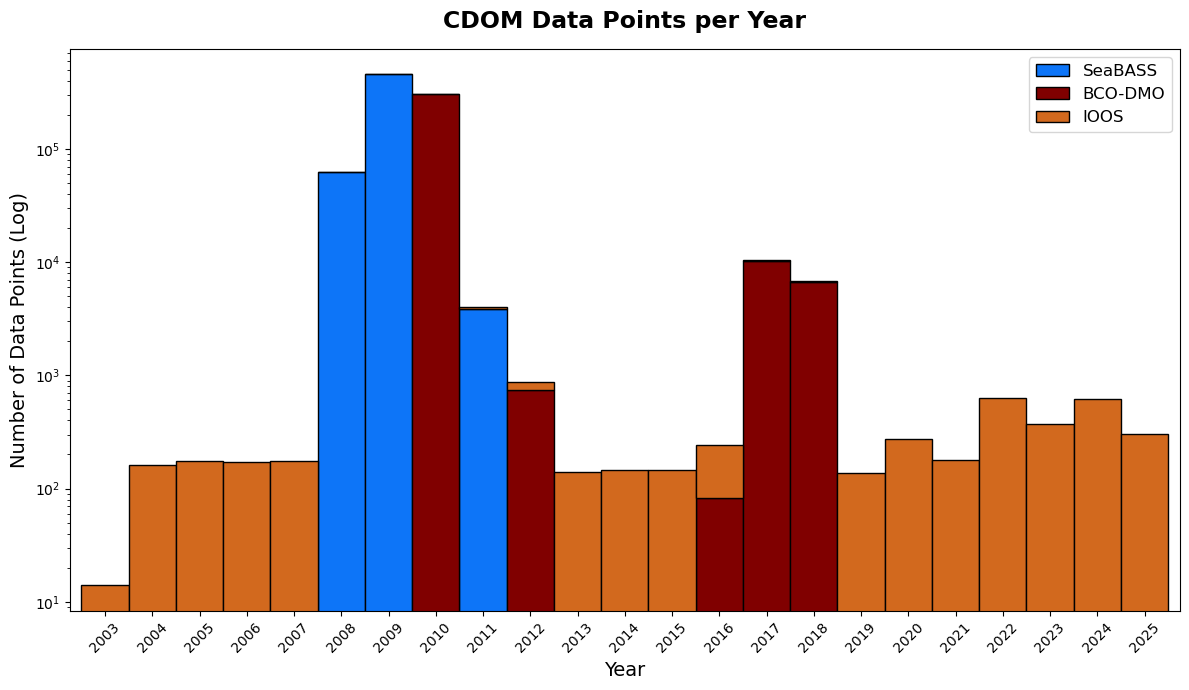

In [7]:
df=cdom.copy()
df['year'] = df['datetime'].dt.year.dropna()
original_sources = sorted(df['source'].unique())

colors = ['maroon', 'chocolate', 'xkcd:deep sky blue']

df = df[(df['year'] <2026)]

color_map = dict(zip(original_sources, colors))

yearly_counts = df.groupby(['year', 'source']).size().unstack(fill_value=0)
source_totals = yearly_counts.sum()
ordered_sources = source_totals.sort_values(ascending=False).index.tolist()
yearly_counts = yearly_counts[ordered_sources]
ordered_colors = [color_map[source] for source in ordered_sources]

ax = yearly_counts.plot(kind='bar', stacked=True, figsize=(12, 7), color=ordered_colors,edgecolor='black',width=1.0, logy=True )

plt.title('CDOM Data Points per Year', fontweight='bold', fontsize=17, pad=15)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Data Points (Log)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

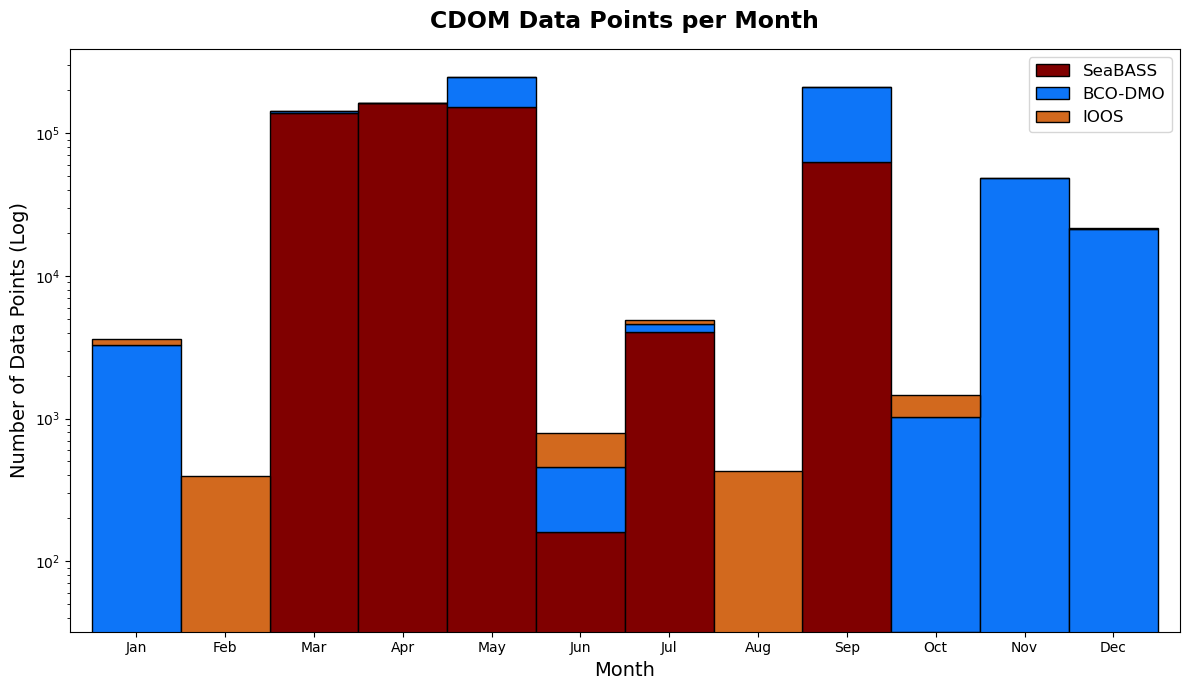

In [8]:
import calendar 
df['month'] = df['datetime'].dt.month.dropna()
original_sources = df['source'].unique()
colors = ['maroon', 'chocolate', 'xkcd:deep sky blue']
color_map = dict(zip(original_sources, colors))
monthly_counts = df.groupby(['month', 'source']).size().unstack(fill_value=0)
source_totals = monthly_counts.sum()
ordered_sources = source_totals.sort_values(ascending=False).index.tolist()
monthly_counts = monthly_counts[ordered_sources]
ordered_colors = [color_map[source] for source in ordered_sources]
monthly_counts.index = [calendar.month_abbr[i] for i in monthly_counts.index]

ax = monthly_counts.plot( kind='bar', stacked=True, figsize=(12, 7), color=ordered_colors, edgecolor='black', width=1.0, logy=True  )
plt.title('CDOM Data Points per Month',fontweight='bold', fontsize=17, pad=15)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Data Points (Log)', fontsize=14)
plt.xticks(rotation=0) 
plt.legend(fontsize=12,  loc='upper right')

plt.tight_layout()
plt.show()

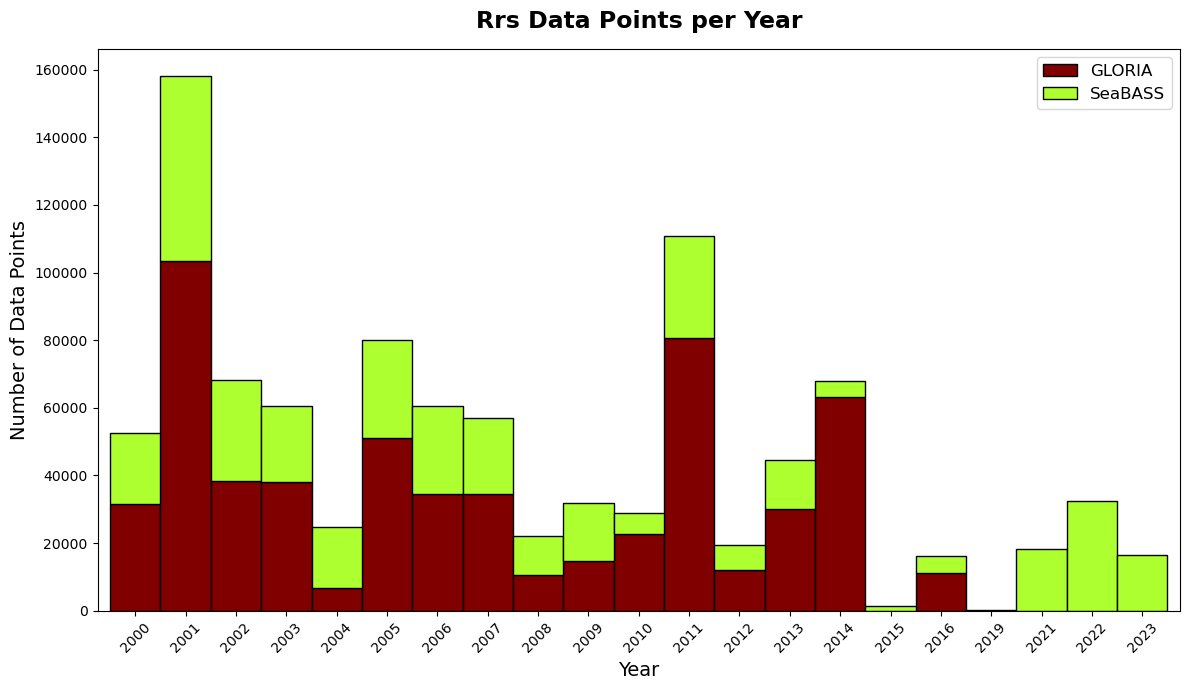

In [10]:
df=rrs.copy()
df['year'] = df['datetime'].dt.year.dropna()
original_sources = sorted(df['source'].unique())

colors = ['maroon', 'greenyellow']

df = df[(df['year'] <2026)]

color_map = dict(zip(original_sources, colors))

yearly_counts = df.groupby(['year', 'source']).size().unstack(fill_value=0)
source_totals = yearly_counts.sum()
ordered_sources = source_totals.sort_values(ascending=False).index.tolist()
yearly_counts = yearly_counts[ordered_sources]
ordered_colors = [color_map[source] for source in ordered_sources]

ax = yearly_counts.plot(kind='bar', stacked=True, figsize=(12, 7), color=ordered_colors,edgecolor='black',width=1.0 )

plt.title('Rrs Data Points per Year', fontweight='bold', fontsize=17, pad=15)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Data Points', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

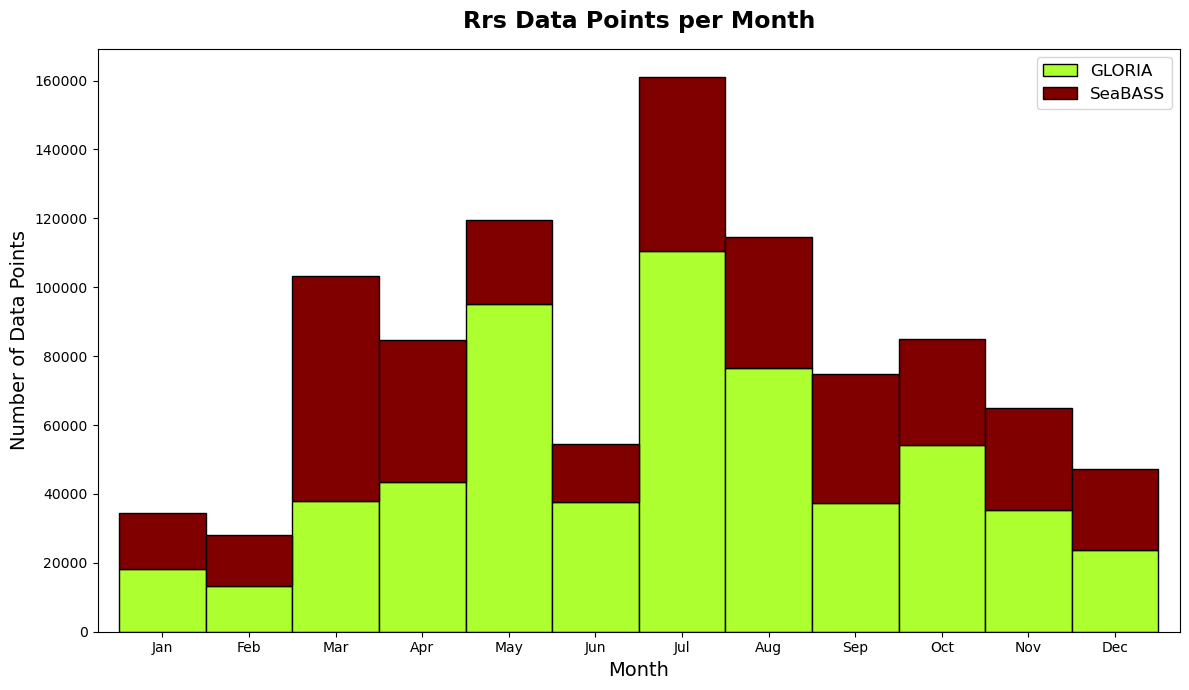

In [11]:
import calendar 
df['month'] = df['datetime'].dt.month.dropna()
original_sources = df['source'].unique()
colors =  ['maroon', 'greenyellow']
color_map = dict(zip(original_sources, colors))
monthly_counts = df.groupby(['month', 'source']).size().unstack(fill_value=0)
source_totals = monthly_counts.sum()
ordered_sources = source_totals.sort_values(ascending=False).index.tolist()
monthly_counts = monthly_counts[ordered_sources]
ordered_colors = [color_map[source] for source in ordered_sources]
monthly_counts.index = [calendar.month_abbr[i] for i in monthly_counts.index]

ax = monthly_counts.plot( kind='bar', stacked=True, figsize=(12, 7), color=ordered_colors, edgecolor='black', width=1.0 )
plt.title('Rrs Data Points per Month',fontweight='bold', fontsize=17, pad=15)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Data Points', fontsize=14)
plt.xticks(rotation=0) 
plt.legend(fontsize=12,  loc='upper right')

plt.tight_layout()
plt.show()

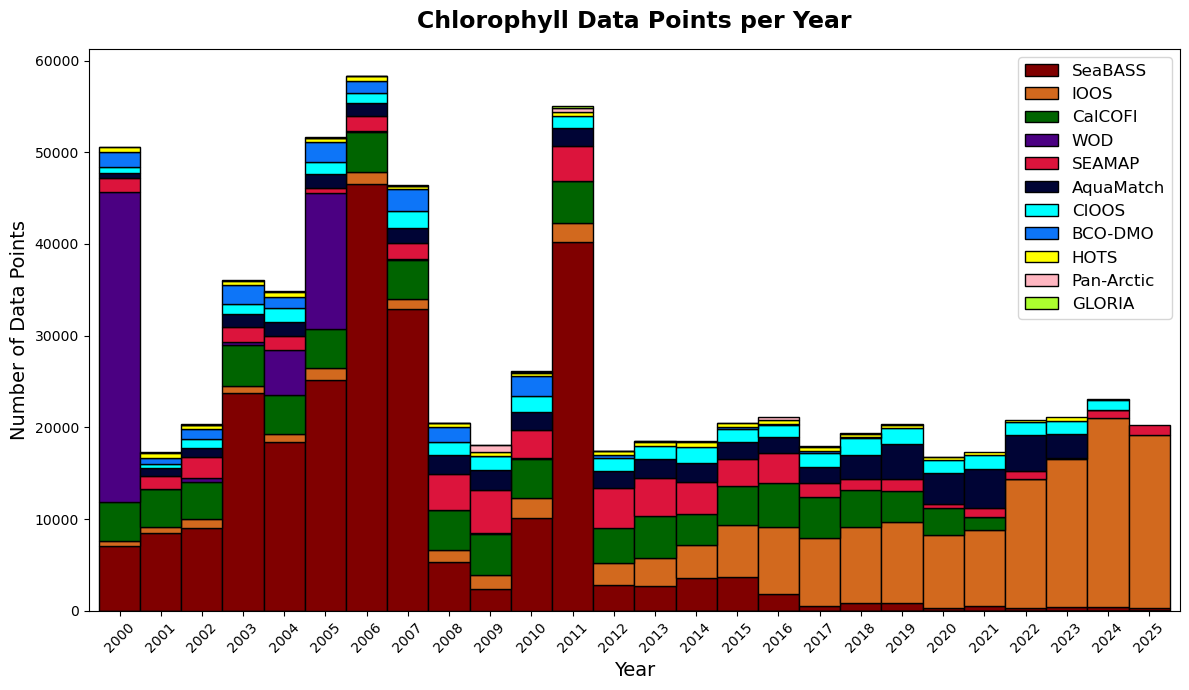

In [26]:
df['year'] = df['datetime'].dt.year.dropna()
original_sources = sorted(df['source'].unique())

colors = ['xkcd:dark navy','xkcd:deep sky blue','aqua', 'darkgreen','greenyellow','yellow','chocolate','lightpink','crimson','maroon','indigo']

df = df[(df['year'] <2026)]

color_map = dict(zip(original_sources, colors))

yearly_counts = df.groupby(['year', 'source']).size().unstack(fill_value=0)
source_totals = yearly_counts.sum()
ordered_sources = source_totals.sort_values(ascending=False).index.tolist()
yearly_counts = yearly_counts[ordered_sources]
ordered_colors = [color_map[source] for source in ordered_sources]

ax = yearly_counts.plot(kind='bar', stacked=True, figsize=(12, 7), color=ordered_colors,edgecolor='black',width=1.0 )

plt.title('Chlorophyll Data Points per Year', fontweight='bold', fontsize=17, pad=15)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Data Points', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

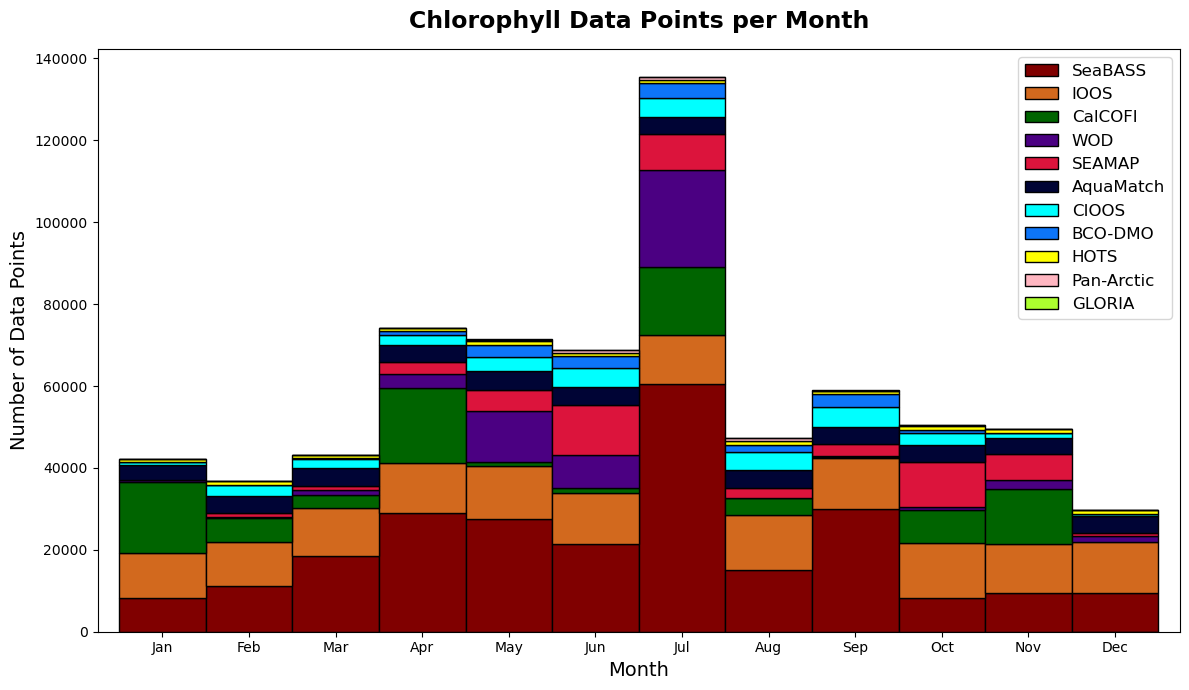

In [27]:
import calendar 
df['month'] = df['datetime'].dt.month.dropna()
original_sources = df['source'].unique()
colors = ['xkcd:dark navy','xkcd:deep sky blue','aqua', 'darkgreen','greenyellow','yellow','chocolate','lightpink','crimson','maroon','indigo']
color_map = dict(zip(original_sources, colors))
monthly_counts = df.groupby(['month', 'source']).size().unstack(fill_value=0)
source_totals = monthly_counts.sum()
ordered_sources = source_totals.sort_values(ascending=False).index.tolist()
monthly_counts = monthly_counts[ordered_sources]
ordered_colors = [color_map[source] for source in ordered_sources]
monthly_counts.index = [calendar.month_abbr[i] for i in monthly_counts.index]

ax = monthly_counts.plot( kind='bar', stacked=True, figsize=(12, 7), color=ordered_colors, edgecolor='black', width=1.0 )
plt.title('Chlorophyll Data Points per Month',fontweight='bold', fontsize=17, pad=15)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Data Points', fontsize=14)
plt.xticks(rotation=0) 
plt.legend(fontsize=12,  loc='upper right')

plt.tight_layout()
plt.show()

# metadata table creation

In [28]:
#first, turn rrs into right format 
def long_to_wide(df):
    """
    Transforms long format to wide format (rrs_###) without averaging duplicates,
    preserving rows even if they have missing metadata (NaNs).
    """
    id_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url',
       'affiliations', 'investigators', 'contact', 'cruise', 'station',
       'ID_code']
    # temporarily fill NaNs with a string so pivot_table doesn't drop them
    df[id_vars] = df[id_vars].fillna('MISSING_DATA')
    
    #group by the full id_vars list to ensure the counter perfectly aligns
    df['temp_counter'] = df.groupby(id_vars + ['wavelength']).cumcount()
    df_wide = df.pivot_table(index=id_vars + ['temp_counter'], columns='wavelength',  values='rrs')
    new_column_names = [f"rrs_{str(col)}" for col in df_wide.columns]
    df_wide.columns = new_column_names
    df_wide = df_wide.reset_index()
    df_wide = df_wide.drop(columns=['temp_counter'])
    return df_wide

rrs2 = long_to_wide(rrs)


In [29]:
print(rrs2.columns[:15])

Index(['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url',
       'affiliations', 'investigators', 'contact', 'cruise', 'station',
       'ID_code', 'rrs_305', 'rrs_320'],
      dtype='object')


In [30]:
rrs2 = rrs2[['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url',
       'affiliations', 'investigators', 'contact', 'cruise', 'station',
       'ID_code']]

In [33]:
dfs=[rrs2,chl, cdom]
all_meta = pd.concat(dfs).reset_index(drop=True)

In [34]:
total_rows = len(all_meta)
percent_data = (all_meta.notna().sum() / total_rows) * 100
print(percent_data)

source            100.000000
datetime          100.000000
lon               100.000000
lat               100.000000
depth             100.000000
experiment        100.000000
DOI_url            94.683169
affiliations       97.086388
investigators      81.752896
contact            18.553092
cruise             59.024638
station            28.828704
ID_code           100.000000
chl                43.508894
chl_a               0.940860
HPLC               43.960894
triplicate         43.960894
data_type_flag     27.951573
cast                5.519189
cdom               52.843770
dtype: float64


# CHL satellite matchups plots

In [2]:
current_matchup = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\sat_matchupCHL2.xlsx')

In [3]:
current_matchup.data_type_flag.value_counts(dropna=False)

data_type_flag
1.0    30784
0.0    30716
NaN     9036
2.0      404
Name: count, dtype: int64

In [21]:

shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\marineecoregions_shapefile\marineecoregions_shapefile\NA_Marine_Ecoregions_2008\data\Marine_Ecoregions_updated.shp')
#all coastal us regions? 
gdf = gpd.GeoDataFrame(current_matchup, geometry=gpd.points_from_xy(current_matchup.lon, current_matchup.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
joined = gpd.sjoin(gdf, shp, how="inner", predicate="within")
#groups_all = dict(tuple(joined.groupby("FishRegion"))) #each group is a polygon 

joined=  pd.DataFrame(joined)
#joined['season'] = joined['datetime'].dt.month.apply(get_season)

In [22]:
#change Names of regions to better fit 
joined = joined.reset_index()
joined.NAME_L1[(joined['NAME_L1'] =='Virginian Atlantic')] = 'Eastern NA'
joined.NAME_L1[(joined['NAME_L1'] =='Northern Gulf Stream Transition',)] = 'Eastern NA'
joined.NAME_L1[(joined['NAME_L1'] =='Acadian Atlantic',)] = 'Eastern NA'
joined.NAME_L1[(joined['NAME_L1'] =='Carolinian Atlantic')] = 'Eastern NA'


joined.NAME_L1[(joined['NAME_L1'] =='Baffin/Labradoran Arctic')] = 'Northern NA'
joined.NAME_L1[(joined['NAME_L1'] =='Hudson/Boothian Arctic')] = 'Northern NA'
#joined.NAME_L1[(joined['NAME_L1'] =='Central Arctic Archipelago',)] = 'N CA/USA'
joined.NAME_L1[(joined['NAME_L1'] =='Arctic Basin')] = 'Northern NA'
joined.NAME_L1[(joined['NAME_L1'] =='Beaufort/Chukchi Seas')] = 'Northern NA'

joined.NAME_L1[(joined['NAME_L1'] =='Bering Sea')] = 'Western NA'
joined.NAME_L1[(joined['NAME_L1'] =='Aleutian Archipelago')] = 'Western NA'
joined.NAME_L1[(joined['NAME_L1'] =='Alaskan/Fjordland Pacific')] = 'Western NA'

joined.NAME_L1[(joined['NAME_L1'] =='Columbian Pacific',)] = 'Western NA'
joined.NAME_L1[(joined['NAME_L1'] =='Montereyan Pacific Transition')] = 'Western NA'
joined.NAME_L1[(joined['NAME_L1'] =='Southern Californian Pacific',)] = 'Western NA'
joined.NAME_L1[(joined['NAME_L1'] =='Gulf of California')] = 'Western NA'
joined.NAME_L1[(joined['NAME_L1'] =='Mexican Pacific Transition')] = 'Western NA'
#joined.NAME_L1[(joined['NAME_L1'] =='Middle American Pacific ')] = 'W USA'

joined.NAME_L1[(joined['NAME_L1'] =='Hawaiian Archipelago')] = 'Hawaii'

joined.NAME_L1[(joined['NAME_L1'] =='Northern Gulf of Mexico',)] = 'Gulf USA'
joined.NAME_L1[(joined['NAME_L1'] =='Southern Gulf of Mexico',)] = 'Gulf USA'
joined.NAME_L1[(joined['NAME_L1'] =='Caribbean Sea',)] = 'Gulf USA'
joined.NAME_L1[(joined['NAME_L1'] =='South Florida/Bahamian Atlantic', )] = 'Gulf USA'

joined=joined[['index', 'datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth',
       'experiment', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag',
       'source', 'chl_occci', 'log_chl', 'log_chl_occci', 'NAME_L1']]

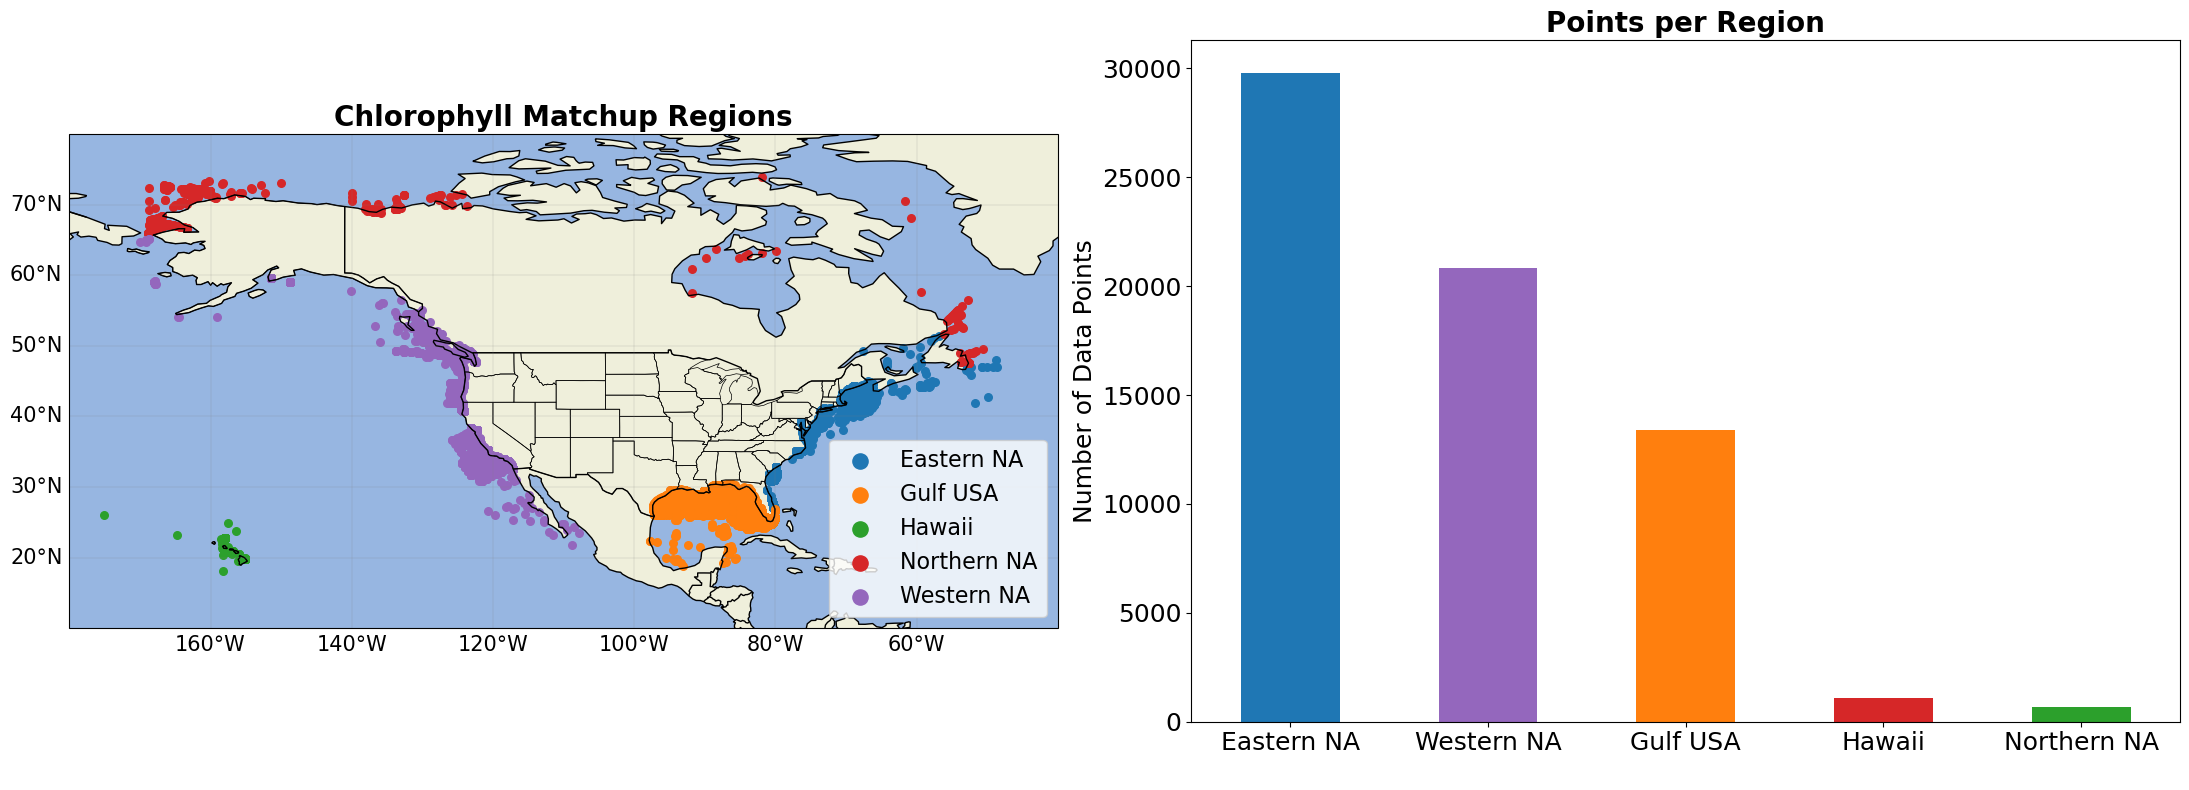

In [19]:
# 2. Setup the subplots (1 row, 2 columns)
fig=plt.figure(figsize=(22, 8))
axs1=fig.add_subplot(1,2,1,projection= cartopy.crs.PlateCarree())
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.COASTLINE)
axs1.add_feature(cfeature.BORDERS)
axs1.add_feature(cfeature.STATES, linestyle='-', linewidth=0.5)
gl=axs1.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
for name, group in joined.groupby('NAME_L1'):
    axs1.scatter(group['lon'], group['lat'], label=name,s=30)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
gl.xlabel_style = {'size': 15, 'color': 'k'}
gl.ylabel_style = {'size': 15, 'color': 'k'}
axs1.set_title('Chlorophyll Matchup Regions', fontsize=20,fontweight='bold')
axs1.legend(fontsize=16,markerscale=2,)
axs1.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())

# 4. Plot the Histogram on the second axis
ax2=fig.add_subplot(1,2,2)
ax2 = joined['NAME_L1'].value_counts().plot(kind='bar',rot=0, color=['tab:blue', 'tab:purple', 'tab:orange', 'tab:red','tab:green'])
ax2.set_title('Points per Region', fontsize=20,fontweight='bold')
ax2.set_xlabel(' ', fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=18)
ax2.set_ylabel('Number of Data Points', fontsize=18)

plt.tight_layout()
plt.show()

In [4]:
current_matchup=current_matchup[[ 'datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth','experiment', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag', 'source',
       'chl_occci']]
current_matchup['log_chl']=np.log10(current_matchup['chl'])
current_matchup['log_chl'] = current_matchup['log_chl'].replace(-np.inf, np.nan)

current_matchup['log_chl_occci']=np.log10(current_matchup['chl_occci'])
current_matchup['log_chl_occci'] = current_matchup['log_chl_occci'].replace(-np.inf, np.nan)

current_matchup['chl_diff'] = current_matchup['log_chl']-current_matchup['log_chl_occci']

#ratio = log_10(chlb/chla)
current_matchup['chl_ratio'] = current_matchup['chl']/current_matchup['chl_occci']
current_matchup['chl_ratio'] = np.log10(current_matchup['chl_ratio'])

#current_matchup['chl_diff'] = current_matchup['chl']-current_matchup['chl_occci']


C:\Users\gianna.milton\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\gianna.milton\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
positive_diff=current_matchup[current_matchup['chl_diff'] >= 0]
positive_diff = positive_diff.sort_values(by='chl_diff', ascending=True)
negative_diff=current_matchup[current_matchup['chl_diff'] < 0]
negative_diff = negative_diff.sort_values(by='chl_diff', ascending=False)

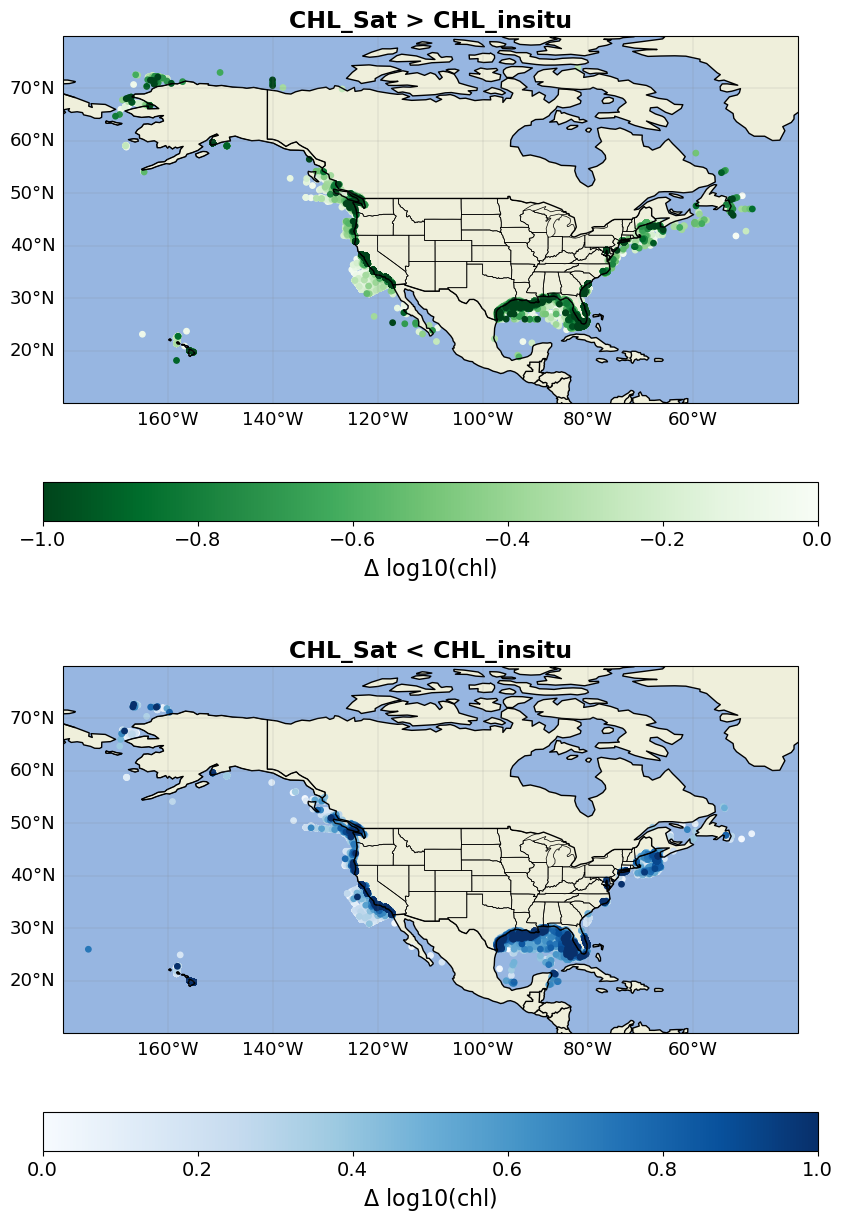

In [6]:
fig=plt.figure(figsize=(10, 15))
axs2=fig.add_subplot(2,1,1,projection= cartopy.crs.PlateCarree())
axs2.add_feature(cfeature.LAND)
axs2.add_feature(cfeature.OCEAN)
axs2.add_feature(cfeature.COASTLINE)
axs2.add_feature(cfeature.BORDERS)
axs2.add_feature(cfeature.STATES, linestyle='-', linewidth=0.5)
gl=axs2.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
gl.xlabel_style = {'size': 13, 'color': 'k'}
gl.ylabel_style = {'size': 13, 'color': 'k'}
im=axs2.scatter(negative_diff.lon,negative_diff.lat,c=negative_diff.chl_diff,cmap='Greens_r',s=15,vmin=-1, vmax=0)
axs2.set_title('CHL_Sat > CHL_insitu',fontweight='bold', fontsize=17)
cb=fig.colorbar(im,ax=axs2,orientation='horizontal')
cb.set_label(r'$\Delta$ log10(chl)',fontsize=16)
axs2.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())
cb.ax.tick_params(labelsize=14) # Adjust '14' to your desired font size

axs1=fig.add_subplot(2,1,2,projection= cartopy.crs.PlateCarree())
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.COASTLINE)
axs1.add_feature(cfeature.BORDERS)
axs1.add_feature(cfeature.STATES, linestyle='-', linewidth=0.5)
gl=axs1.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
gl.xlabel_style = {'size': 13, 'color': 'k'}
gl.ylabel_style = {'size': 13, 'color': 'k'}
im=axs1.scatter(positive_diff.lon,positive_diff.lat,c=positive_diff.chl_diff,cmap='Blues',s=15,vmin=0, vmax=1)
axs1.set_title('CHL_Sat < CHL_insitu',fontweight='bold', fontsize=17)
axs1.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())
cb=fig.colorbar(im,ax=axs1,orientation='horizontal')
cb.set_label(r'$\Delta$ log10(chl)',fontsize=16)
cb.ax.tick_params(labelsize=14) # Adjust '14' to your desired font size


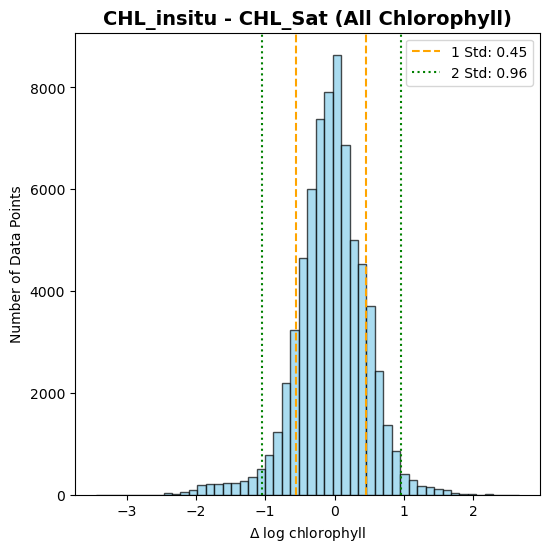

In [8]:
mean = current_matchup['chl_diff'].mean()
std = current_matchup['chl_diff'].std()
plt.figure(figsize=(6, 6))
current_matchup['chl_diff'].hist(bins=50, color='skyblue', edgecolor='black', alpha=0.7,grid=False)

# 3. Add vertical lines for mean and std deviations
#plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean:.2f}')
plt.axvline(mean + std, color='orange', linestyle='--', label=f'1 Std: {mean + std:.2f}')
plt.axvline(mean - std, color='orange', linestyle='--')
plt.axvline(mean + 2*std, color='green', linestyle=':', label=f'2 Std: {mean + 2*std:.2f}')
plt.axvline(mean - 2*std, color='green', linestyle=':')

# Formatting
plt.title('CHL_insitu - CHL_Sat (All Chlorophyll)',fontweight='bold',size=14)
plt.xlabel(r'$\Delta$ log chlorophyll')
plt.ylabel('Number of Data Points')
plt.legend()
plt.show()

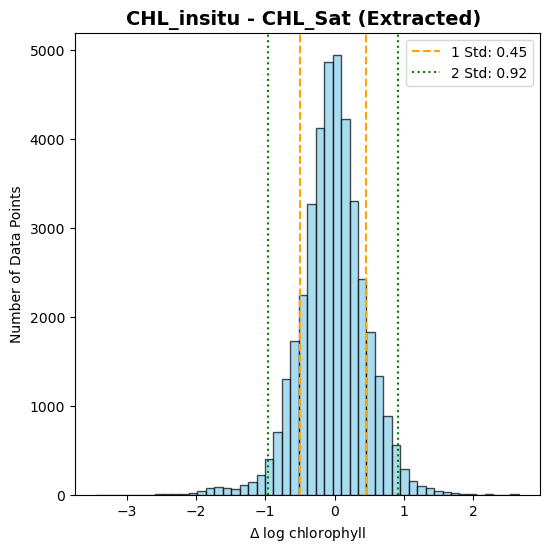

In [9]:
#subset to only in vitro values 
current_matchup_extracted=current_matchup[current_matchup['data_type_flag'] != 1]
mean = current_matchup_extracted['chl_diff'].mean()
std = current_matchup_extracted['chl_diff'].std()
plt.figure(figsize=(6, 6))
current_matchup_extracted['chl_diff'].hist(bins=50, color='skyblue', edgecolor='black', alpha=0.7,grid=False)

# 3. Add vertical lines for mean and std deviations
#plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean:.2f}')
plt.axvline(mean + std, color='orange', linestyle='--', label=f'1 Std: {mean + std:.2f}')
plt.axvline(mean - std, color='orange', linestyle='--')
plt.axvline(mean + 2*std, color='green', linestyle=':', label=f'2 Std: {mean + 2*std:.2f}')
plt.axvline(mean - 2*std, color='green', linestyle=':')

# Formatting
plt.title('CHL_insitu - CHL_Sat (Extracted) ',fontweight='bold',size=14)
plt.xlabel(r'$\Delta$ log chlorophyll')
plt.ylabel('Number of Data Points')
plt.legend()
plt.show()

In [13]:
df_new = add_distance_to_shore(current_matchup_extracted)

C:\Users\gianna.milton\AppData\Local\Temp\ipykernel_20164\2230331856.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  unified_land = land_metric.geometry.unary_union


Done!


C:\Users\gianna.milton\AppData\Local\Temp\ipykernel_20164\2230331856.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dist_to_shore_km'] = gdf_metric.geometry.distance(unified_land) / 1000


In [14]:
df_new=df_new.sort_values(by='dist_to_shore_km')

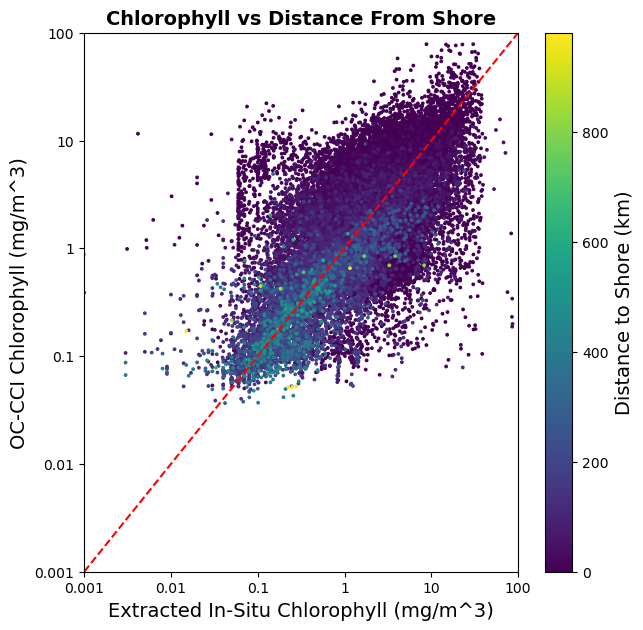

In [15]:
custom_x_ticks = [-3, -2, -1, 0, 1, 2,3] #-3,3
custom_x_labels = [0.001 , 0.01, 0.1, 1, 10, 100, None] 

fig, axs2 = plt.subplots(figsize=(7, 7))
im=axs2.scatter(df_new['log_chl'], df_new['log_chl_occci'], c=df_new['dist_to_shore_km'], cmap='viridis',s=3,vmin=0, vmax=980)
axs2.set_title('Chlorophyll vs Distance From Shore',fontweight='bold',size=14)
cb=fig.colorbar(im,ax=axs2,orientation='vertical')
cb.set_label('Distance to Shore (km)',fontsize=14)
axs2.set_xlabel('Extracted In-Situ Chlorophyll (mg/m^3)',fontsize=14)
axs2.set_ylabel('OC-CCI Chlorophyll (mg/m^3)',fontsize=14)
axs2.set_yticks(custom_x_ticks)
axs2.set_yticklabels(custom_x_labels)
axs2.set_xticks(custom_x_ticks)
axs2.set_xticklabels(custom_x_labels)
axs2.set_xlim(-3, 2)
axs2.set_ylim(-3, 2)
axs2.plot([-3, 3], [-3, 3], "r--", lw=1.5)

#min_val = min(df_new['log_chl'].min(), df_new['log_chl_occci'].min())
#max_val = max(df_new['log_chl'].max(), df_new['log_chl_occci'].max())
#plt.plot([min_val, max_val], [min_val, max_val], 'b--', label='1:1 Reference Line', zorder=1)


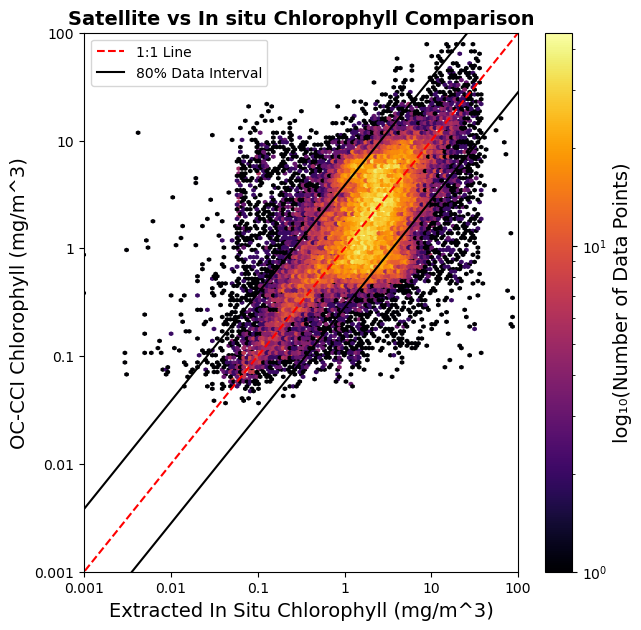

In [16]:
def plot_chl_comp(ds_x, ds_y, x_var, y_var, xlab="In Situ", ylab="OC-CCI", title=None, data_interval=80):
    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))
    def calculate_stats(x, y):
        return (np.mean(y - x),               # bias
            mean_absolute_error(x, y),    # MAE
            root_mean_squared_error(x, y),# RMSE
            r2_score(x, y))               # R²
    x = ds_x[x_var].values
    y = ds_y[y_var].values

    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    stats = calculate_stats(x, y)
    line_min = min(x.min(), y.min()) - 2
    line_max = max(x.max(), y.max()) + 2

    fig, ax = plt.subplots(figsize=(7, 7))
    hb = ax.hexbin(x, y, gridsize=130, cmap="inferno", mincnt=1, bins="log")

    ax.plot([line_min, line_max], [line_min, line_max], "r--", lw=1.5, label="1:1 Line")
    
    #calculate the distance of every point from the 1:1 line
    diff = y - x
    
    #determine the percentile bounds (e.g., 5 and 95 for a 90% interval)
    lower_percentile = (100 - data_interval) / 2.0
    upper_percentile = 100 - lower_percentile
    
    lower_bound = np.percentile(diff, lower_percentile)
    upper_bound = np.percentile(diff, upper_percentile)
    
    #plot the interval lines parallel to the 1-1 line
    ax.plot([line_min, line_max], [line_min + lower_bound, line_max + lower_bound], "k-", lw=1.5, label=f"{data_interval}% Data Interval")
    ax.plot([line_min, line_max], [line_min + upper_bound, line_max + upper_bound], "k-", lw=1.5)
    ax.set_xlabel(f"Extracted {xlab} Chlorophyll (mg/m^3)",size=14)
    ax.set_ylabel(f"{ylab} Chlorophyll (mg/m^3)",size=14)

    ax.set_yticks(custom_x_ticks)
    ax.set_yticklabels(custom_x_labels)
    ax.set_xticks(custom_x_ticks)
    ax.set_xticklabels(custom_x_labels)
    #title = ('Satellite to In Situ Chlorophyll Comparison',fontweight='bold',size=14)
            
    ax.set_xlim(-3, 2)
    ax.set_ylim(-3, 2)
    ax.set_title('Satellite vs In situ Chlorophyll Comparison',fontweight='bold',size=14)
    ax.legend(loc="upper left")
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("log₁₀(Number of Data Points)",size=14)
    plt.show()

plot_chl_comp(ds_x=current_matchup_extracted, ds_y=current_matchup_extracted, x_var='log_chl', y_var='log_chl_occci')

# OWT plots

In [36]:
current_matchup = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\owt_allchlV3.xlsx')
current_owt=current_matchup[['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment',  'HPLC', 'triplicate', 'data_type_flag', 'source',
       'chl_occci', 'owt', 'all_classes']]
current_owt = current_owt.dropna(subset=['owt'])
current_owt['datetime'] = current_owt['datetime'].apply(pd.to_datetime)
current_owt=current_owt[current_owt['data_type_flag'] != 1] #only keep extracted values


In [24]:
print(len(current_owt)) #317,779 (this is less than the chl dataset because i reduced to date hour) ->62435

36010


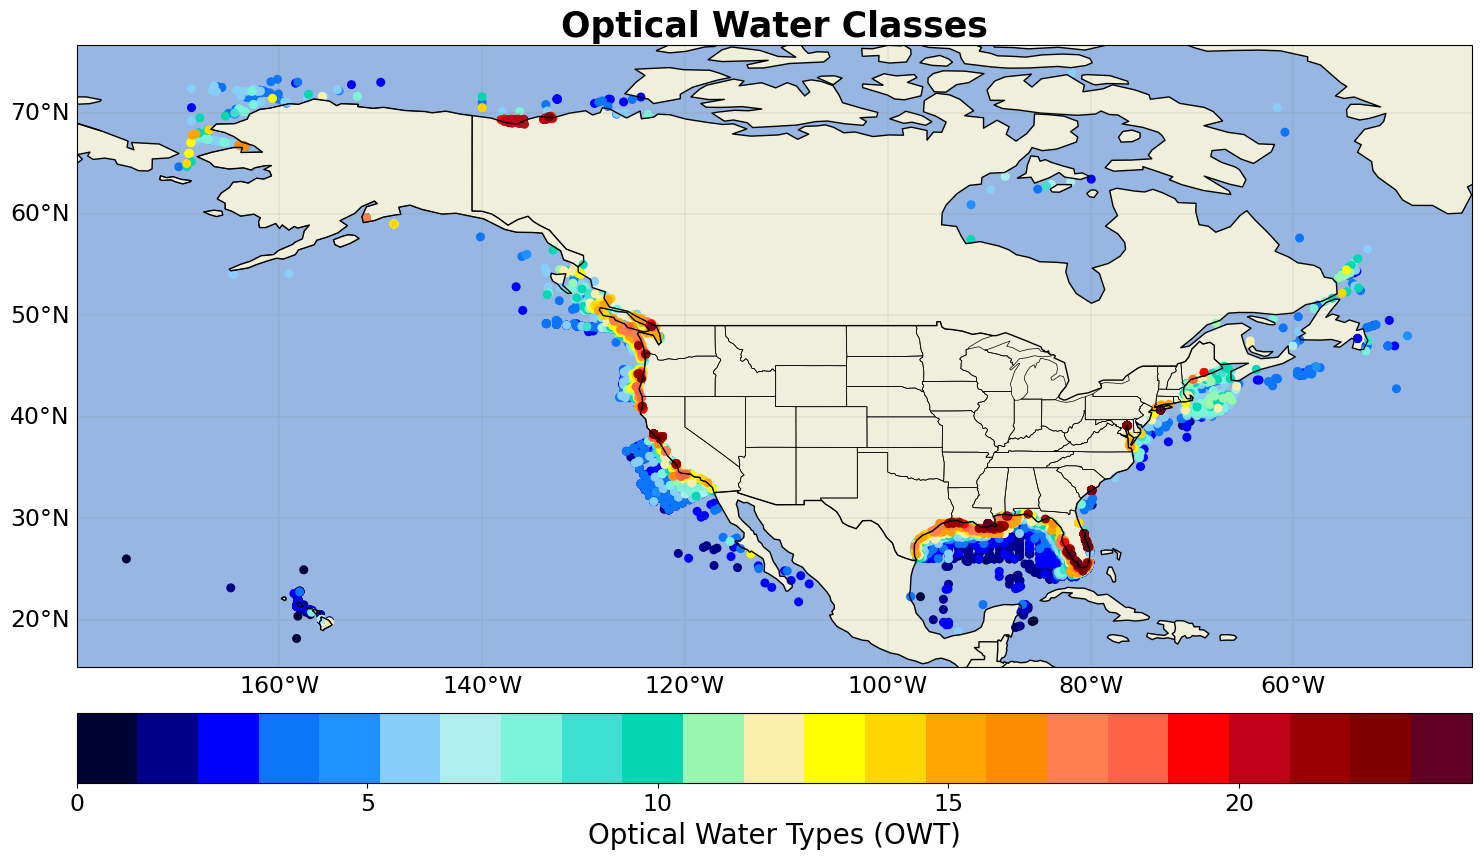

In [26]:
colors = ['xkcd:dark navy','darkblue','blue','xkcd:deep sky blue','dodgerblue','lightskyblue','paleturquoise', 'xkcd:tiffany blue','turquoise','xkcd:aquamarine', 
          'xkcd:light sea green','xkcd:light tan',
          'yellow','gold','orange','darkorange','coral','tomato','red','xkcd:scarlet','xkcd:blood red','maroon','xkcd:burgundy']
color_bar_custom = mcolors.ListedColormap(colors)
test3 = current_owt.sort_values(by='owt')#organize by class

fig, axs1= plt.subplots(subplot_kw={'projection': cartopy.crs.PlateCarree()},figsize=(18, 12) )
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.COASTLINE)
axs1.add_feature(cfeature.BORDERS)
axs1.add_feature(cfeature.STATES, linestyle='-', linewidth=0.5)
gl=axs1.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
im=axs1.scatter(test3.lon,test3.lat,c=test3.owt,cmap=color_bar_custom,s=30, vmin=0, vmax=24)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style = {'size': 17, 'color': 'k'}
gl.ylabel_style = {'size': 17, 'color': 'k'}
cb=fig.colorbar(im,ax=axs1,orientation='horizontal',pad=0.05)
axs1.set_title('Optical Water Classes', fontsize=25, fontweight='bold')
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
cb.set_label('Optical Water Types (OWT)',fontsize=20)
cb.ax.tick_params(labelsize=17) # Adjust '14' to your desired font size


In [27]:
current_owt['log_chl'] = np.log10(current_owt['chl'])
current_owt['log_chl'] = current_owt['log_chl'].replace(-np.inf, np.nan)

current_owt['log_chl_a'] = np.log10(current_owt['chl_a'])
current_owt['log_chl_a'] = current_owt['log_chl_a'].replace(-np.inf, np.nan)

current_owt['log_chl_occci'] = np.log10(current_owt['chl_occci'])
current_owt['log_chl_occci'] = current_owt['log_chl_occci'].replace(-np.inf, np.nan)


C:\Users\gianna.milton\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [28]:
current_owt = add_distance_to_shore(current_owt)

C:\Users\gianna.milton\AppData\Local\Temp\ipykernel_20164\2230331856.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  unified_land = land_metric.geometry.unary_union


Done!


In [29]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
def calculate_stats(x, y):
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    return (np.mean(y - x),               # bias
        mean_absolute_error(x, y),    # MAE
        root_mean_squared_error(x, y),# RMSE
        r2_score(x, y))     

Text(0.5, 0.98, 'Satellite vs Extracted In-Situ Chlorophyll grouped by OWT')

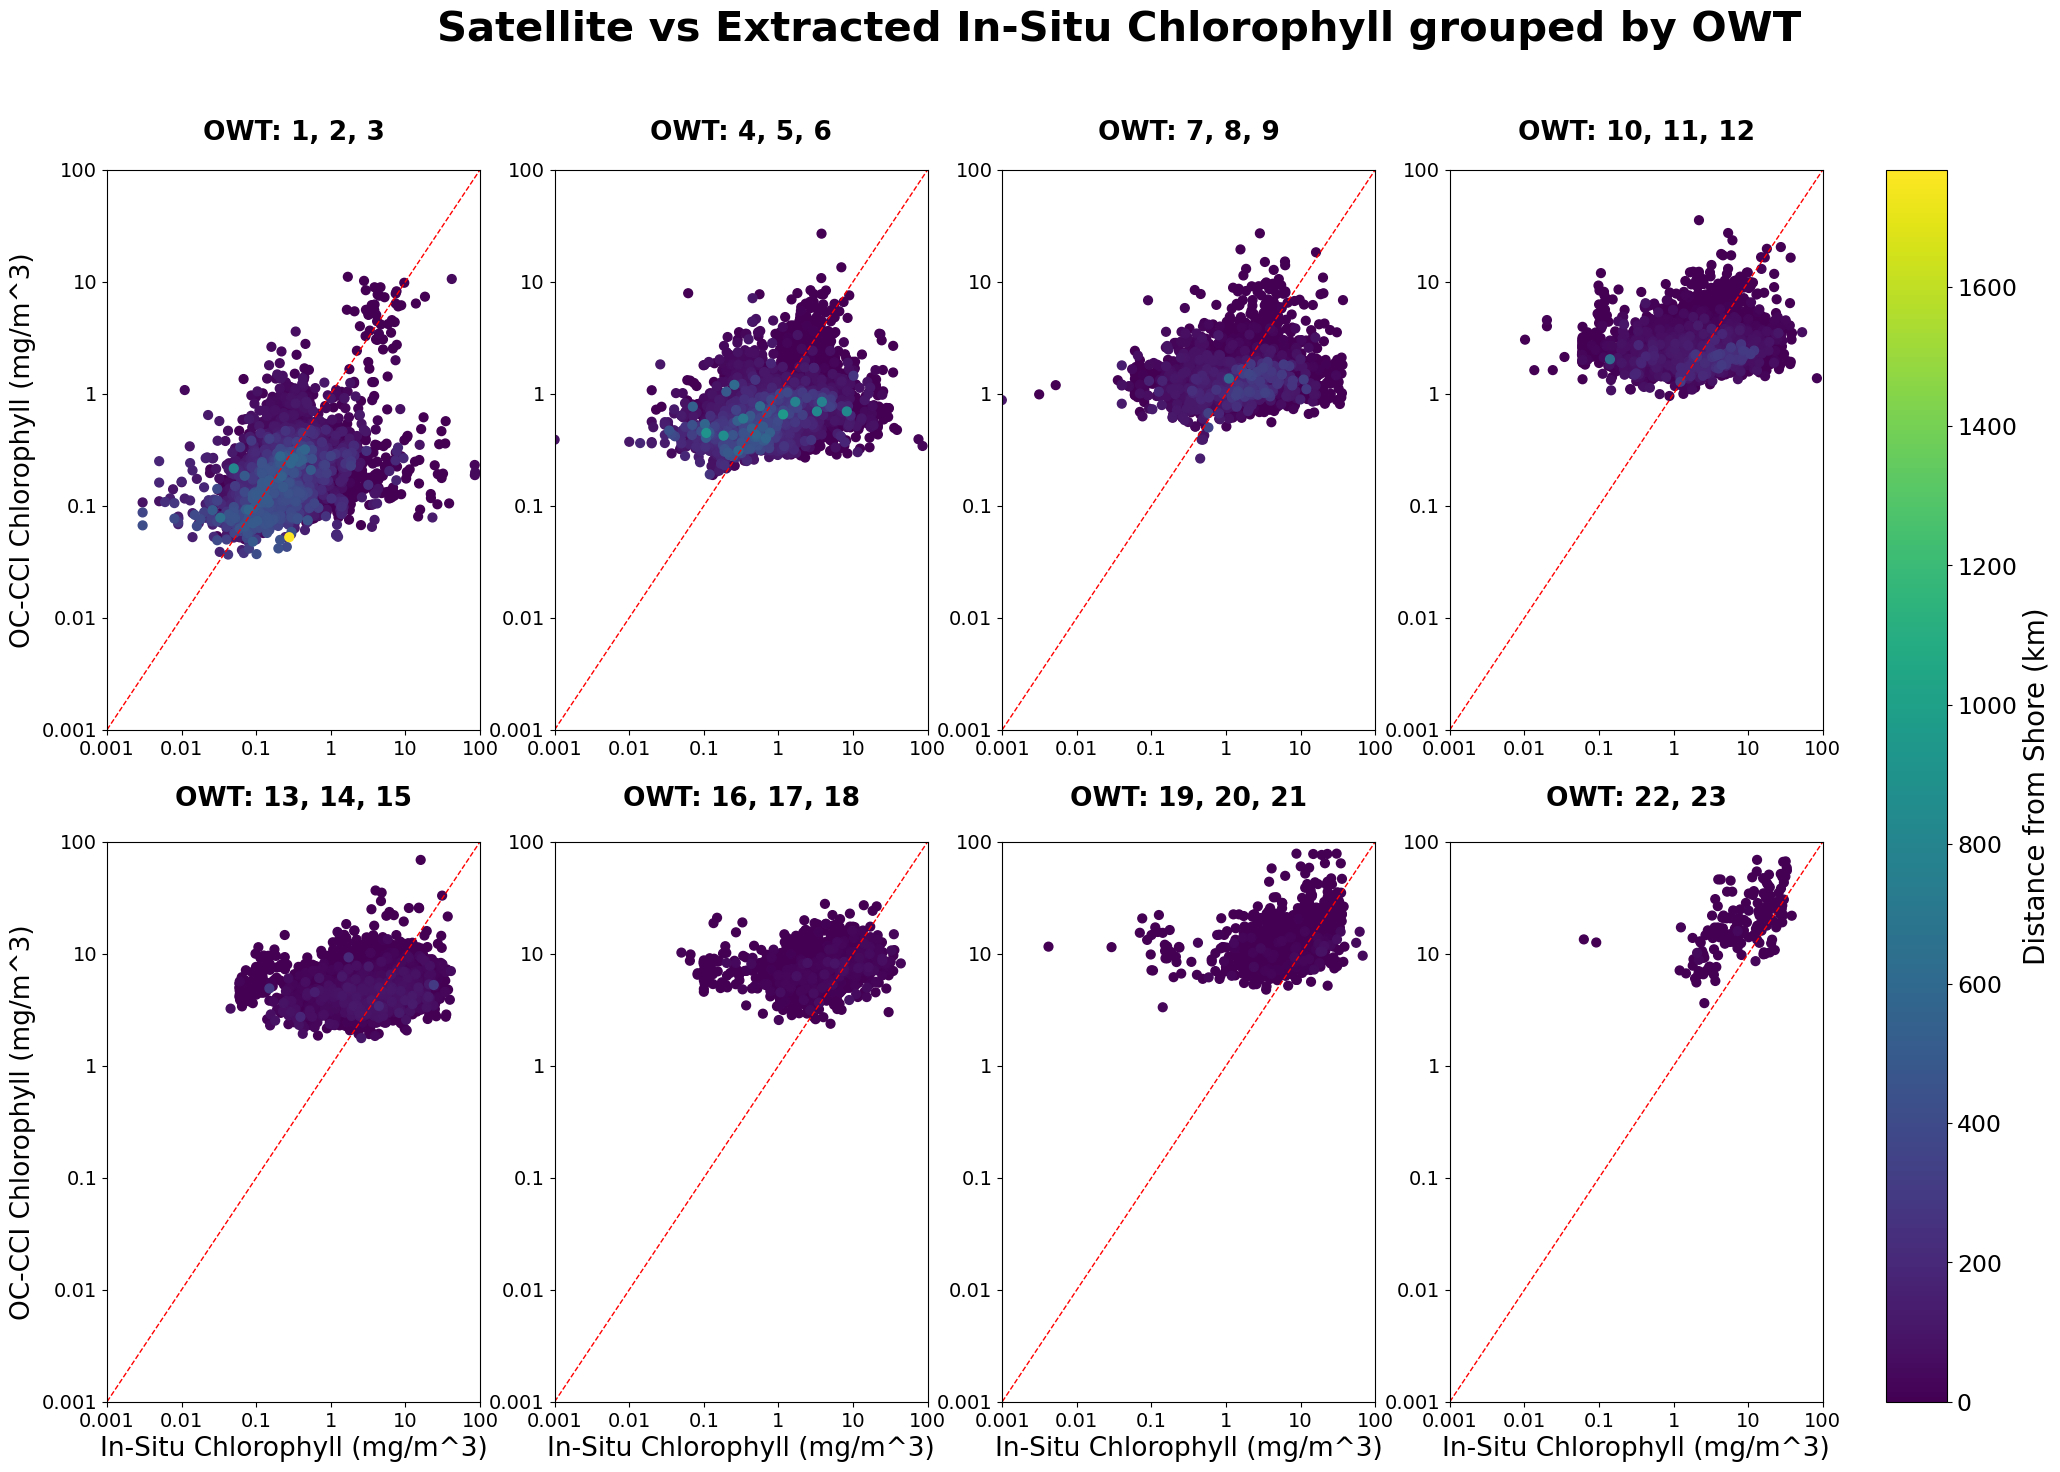

In [30]:
owt_groups = [[1, 2, 3],[4, 5, 6],[7, 8, 9], [10, 11, 12],[13, 14, 15],[16, 17, 18], [19, 20, 21],  [22, 23]]
vmin = current_owt['dist_to_shore_km'].min()
vmax = current_owt['dist_to_shore_km'].max()
custom_x_ticks = [-3, -2, -1, 0, 1, 2,3] #-3,3
custom_x_labels = [0.001 , 0.01, 0.1, 1, 10, 100, None] 

df = current_owt.copy()
df=df.sort_values(by='dist_to_shore_km')
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(27, 16), sharex=True, sharey=True)
axes = axes.flatten()
for i, (ax, group) in enumerate(zip(axes, owt_groups)):
    subset = df[df['owt'].isin(group)]
    scatter = ax.scatter(x=subset['log_chl'], y=subset['log_chl_occci'], c=subset['dist_to_shore_km'], cmap='viridis',s=40, vmin=vmin, vmax=vmax)

    #stats = calculate_stats(subset['log_chl'], subset['log_chl_occci'])

    ax.set_yticks(custom_x_ticks)
    ax.set_yticklabels(custom_x_labels)
    ax.set_xticks(custom_x_ticks)
    ax.set_xticklabels(custom_x_labels)
    
    group_str = ", ".join(map(str, group))
    ax.set_title(f'OWT: {group_str}\n', fontsize=19, pad=0.3, fontweight='bold')
    ax.tick_params(labelbottom=True, labelleft=True)
    if i >= 4: # Bottom row gets X labels
        ax.set_xlabel('In-Situ Chlorophyll (mg/m^3)', fontsize=19)
    if i % 4 == 0: # First column gets Y labels
        ax.set_ylabel('OC-CCI Chlorophyll (mg/m^3)', fontsize=19)
    ax.set_xlim(-3,2)
    ax.set_ylim(-3,2)
    ax.plot([-3, 3], [-3, 3], "r--", lw=1)
    ax.tick_params(axis='both', labelsize=14)

cbar = fig.colorbar(scatter, ax=axes, orientation='vertical', pad=0.03)
cbar.set_label('Distance from Shore (km)', fontsize=20)
cbar.ax.tick_params(labelsize=17) # Adjust '14' to your desired font size
#ax.tick_params(axis='x', labelsize=14)

# Add a main title for the entire figure
fig.suptitle('Satellite vs Extracted In-Situ Chlorophyll grouped by OWT', fontsize=30, fontweight='bold')


[Text(0, 0, '1'),
 Text(1, 0, '2'),
 Text(2, 0, '3'),
 Text(3, 0, '4'),
 Text(4, 0, '5'),
 Text(5, 0, '6'),
 Text(6, 0, '7'),
 Text(7, 0, '8'),
 Text(8, 0, '9'),
 Text(9, 0, '10'),
 Text(10, 0, '11'),
 Text(11, 0, '12'),
 Text(12, 0, '13'),
 Text(13, 0, '14'),
 Text(14, 0, '15'),
 Text(15, 0, '16'),
 Text(16, 0, '17'),
 Text(17, 0, '18'),
 Text(18, 0, '19'),
 Text(19, 0, '20'),
 Text(20, 0, '21'),
 Text(21, 0, '22'),
 Text(22, 0, '23')]

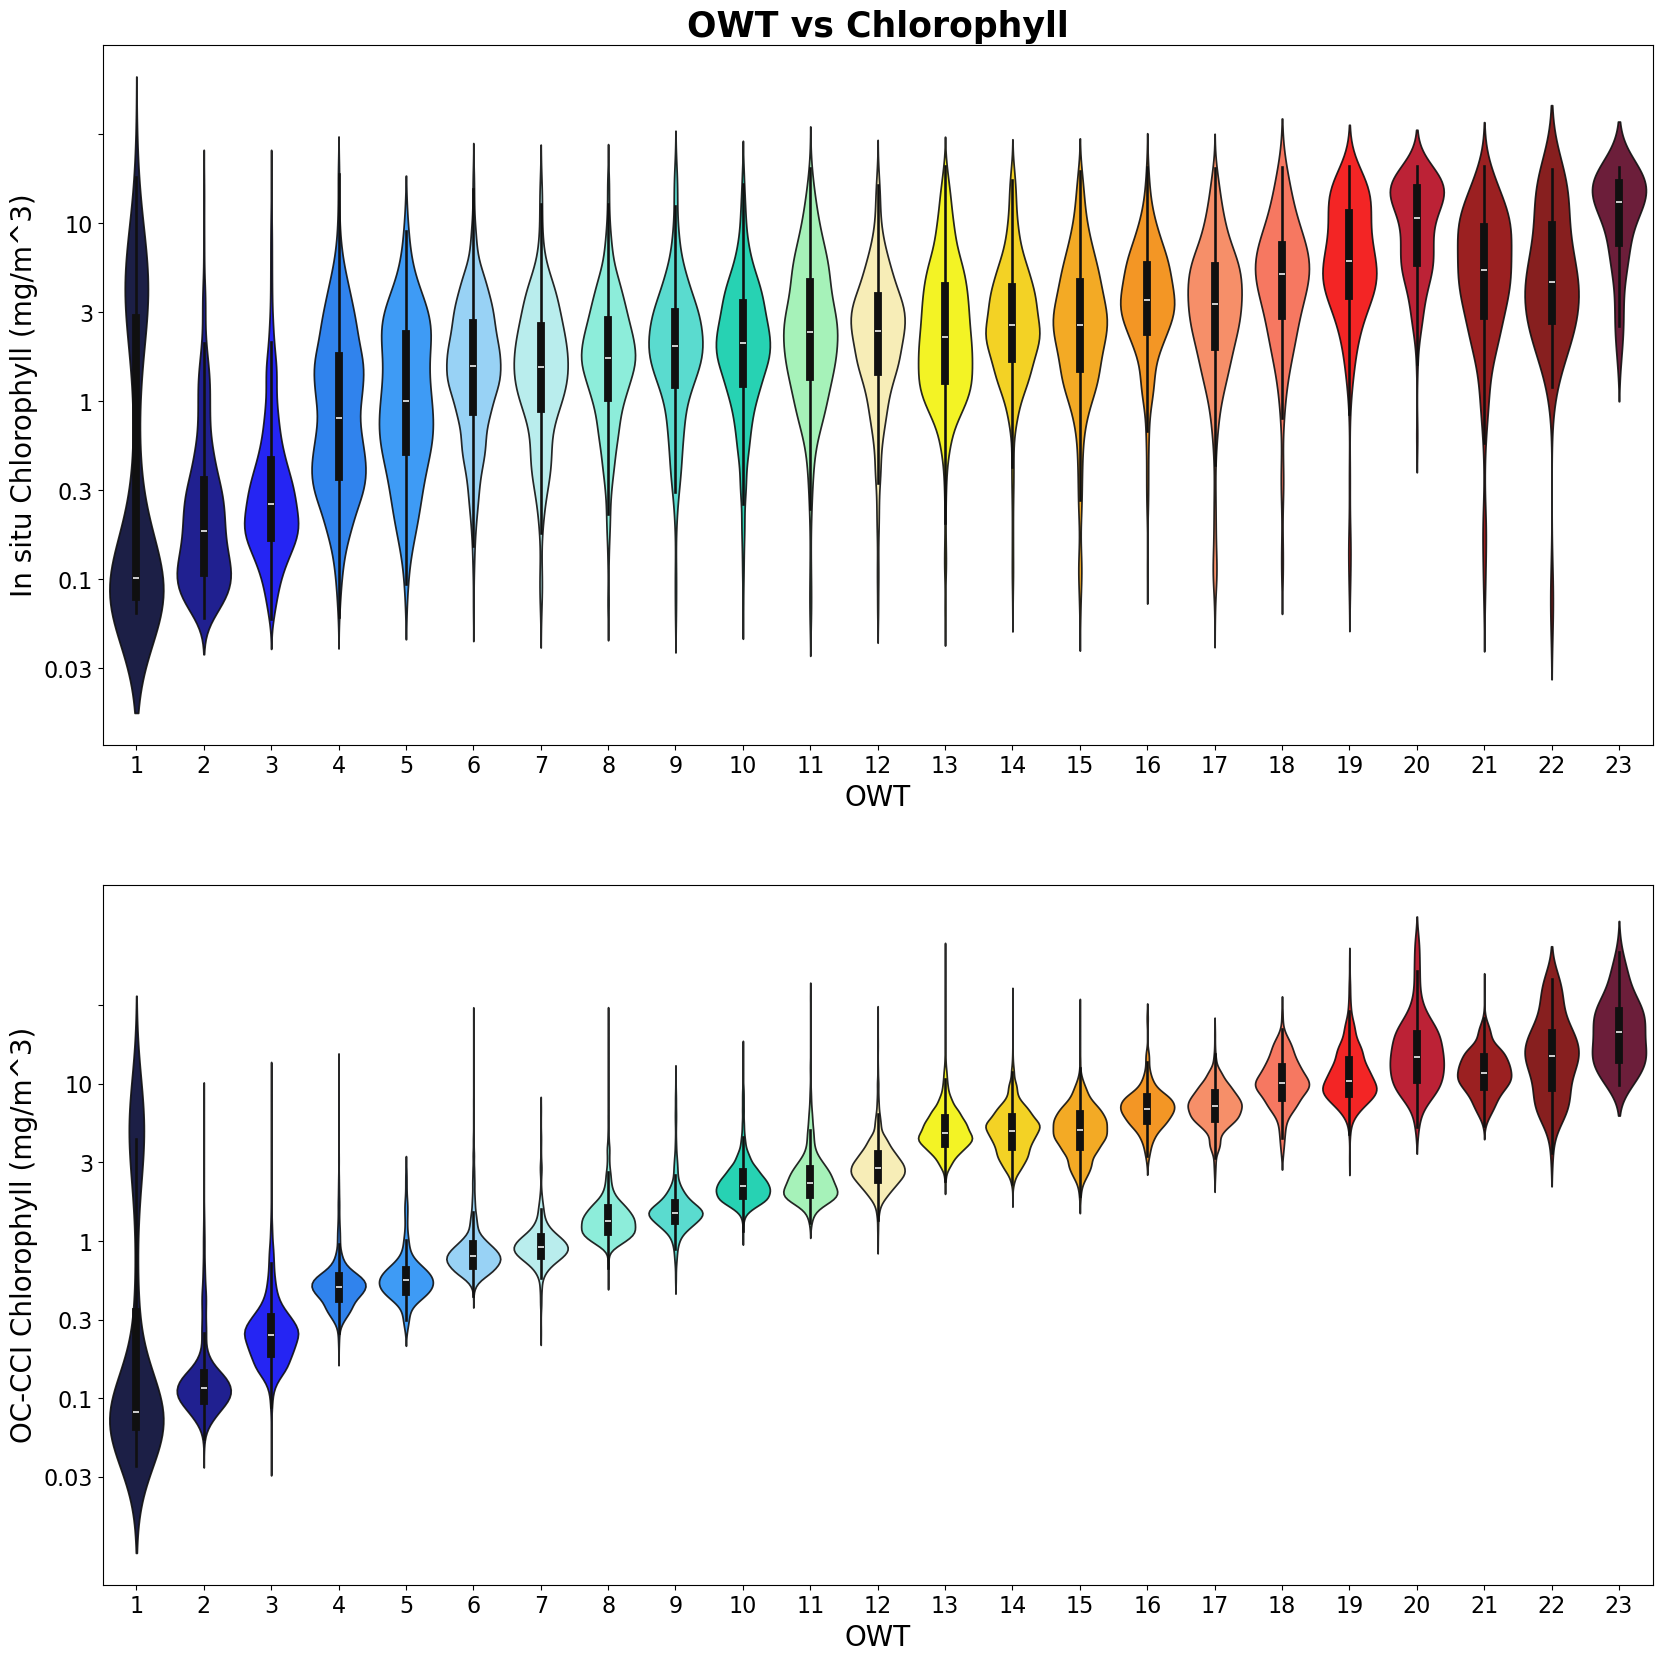

In [31]:
test3 = current_owt.sort_values(by='owt')#organize by class
percentage_trim = 0.01
q_low = test3['log_chl'].quantile(percentage_trim)
q_high = test3['log_chl'].quantile(1 - percentage_trim)
filtered_df = test3[(test3['log_chl'] > q_low) & (test3['log_chl'] < q_high)]
def format_func(value, tick_number): #have x axis lables without decimals (1.0 -> 1)
    return f'{int(value)}'

fig=plt.figure(figsize=(20,20))
axs1=fig.add_subplot(2,1,1)
sns.violinplot(data=filtered_df,x='owt',y='log_chl',hue='owt',palette=color_bar_custom, ax = axs1,alpha=0.9, saturation=0.9, legend=False)
axs1.set_title('OWT vs Chlorophyll', fontsize=25, fontweight='bold')
axs1.tick_params(axis='x', labelsize=16)
axs1.tick_params(axis='y', labelsize=16)
axs1.set_ylabel("In situ Chlorophyll (mg/m^3)", fontsize=20)
axs1.set_xlabel("OWT", fontsize=20)
custom_y_ticks = [-1.5, -1, -0.5,0, 0.5, 1, 1.5]
custom_y_labels = [0.03, 0.1, 0.3, 1, 3,10, None]
axs1.set_yticks(custom_y_ticks)
axs1.set_yticklabels(custom_y_labels)
custom_x_ticks = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22]
custom_x_labels = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]
axs1.set_xticks(custom_x_ticks)
axs1.set_xticklabels(custom_x_labels)

axs2=fig.add_subplot(2,1,2)
sns.violinplot(data=filtered_df,x='owt',y='log_chl_occci',hue='owt',palette=color_bar_custom, ax = axs2,alpha=0.9, saturation=0.9, legend=False)
axs2.tick_params(axis='x', labelsize=16)
axs2.tick_params(axis='y', labelsize=16)
axs2.set_ylabel("OC-CCI Chlorophyll (mg/m^3)", fontsize=20)
axs2.set_xlabel("OWT", fontsize=20)
axs2.xaxis.set_major_formatter(FuncFormatter(format_func))
axs2.set_yticks(custom_y_ticks)
axs2.set_yticklabels(custom_y_labels)
axs2.set_xticks(custom_x_ticks)
axs2.set_xticklabels(custom_x_labels)

In [34]:
current_owt.columns

Index(['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'HPLC',
       'triplicate', 'data_type_flag', 'source', 'chl_occci', 'owt', 'log_chl',
       'log_chl_a', 'log_chl_occci', 'dist_to_shore_km'],
      dtype='object')

In [ ]:
current_owt['all_classes'] = current_owt['all_classes'].str.replace('nan', 'None')
current_owt['all_classes'] = current_owt['all_classes'].apply(ast.literal_eval) #change from str

matched_all['class_variance']=0 #does the 3x3 grid have more than 3 distinct classes?
matched_all['range_flag']=0 #is the range in the 3x3 grid larger than 1? 
matched_all['pair']=None #what are the most common pairs of water class in the 3x3 grid? 
for index, row in matched_all.iterrows():
    no_nans = [x for x in row['all_classes'] if x is not None]
    lists = list(set(no_nans)) #for calculating if the varience is +-1 or over 
    if len(lists)>1:   #if there are more than 1 items in the list
        if (max(lists)-min(lists)>2):       #if the change is greater than 1? what about 2?
             matched_all.loc[index,'range_flag']=1 #the change is greater than 1 so flag
        else:
            matched_all.loc[index,'range_flag']=0
    a = Counter(no_nans) #find how many of each classification are in it 
    b=a.most_common() #organize by most common to least 
    if b[0][1]>5: #if the second item in the list (the number of occurances) is greater than 5, 
        matched_all.loc[index,'class_variance']=0 #not high variance
    else: 
        matched_all.loc[index,'class_variance']=1 #if the most common value is less than 1, flag it 
    if len(b)>1:
        single_pair = [b[0][0],b[1][0]]
        matched_all.at[index,'pair']=single_pair


In [ ]:
regions = [ 'North Pacific','Pacific',  'Western Pacific','East_coast','Gulf of Mexico']
titles = [ 'Alaska','West Coast', 'Hawaii','East Coast', 'Gulf of Mexico']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(9,9))
axes = axes.flatten()
for i, region in enumerate(regions):
    data = groups_updated[region].class_variance
    weights = np.ones_like(data) / len(data)
    axes[i].hist(data, bins=2, weights=weights, color='skyblue', edgecolor='black')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('Percentage')
    axes[i].set_ylim(0, 1)

plt.subplots_adjust(wspace=0.4, hspace=0.3)
plt.suptitle('does the area have alot of variation? 0=no, 1=yes', fontsize=16, fontweight='bold')
plt.show()

## details on each source for paper

In [2]:
def long_to_wide(df):
    """
    Transforms long format to wide format (rrs_###) without averaging duplicates,
    preserving rows even if they have missing metadata (NaNs).
    """
    id_vars = ['datetime', 'lon', 'lat']
    df_temp = df.copy()
    # temporarily fill NaNs with a string so pivot_table doesn't drop them
    df_temp[id_vars] = df_temp[id_vars].fillna('MISSING_DATA')
    
    #group by the full id_vars list to ensure the counter perfectly aligns
    df_temp['temp_counter'] = df_temp.groupby(id_vars + ['wavelength']).cumcount()
    df_wide = df_temp.pivot_table(index=id_vars + ['temp_counter'], columns='wavelength',  values='rrs')
    new_column_names = [f"rrs_{str(col)}" for col in df_wide.columns]
    df_wide.columns = new_column_names
    df_wide = df_wide.reset_index()
    df_wide = df_wide.drop(columns=['temp_counter'])
    return df_wide

In [5]:
CalCOFI = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\calcofi_chl_qc.xlsx')
print('CalCOFI ' + str(min(CalCOFI.datetime)) + ' -> ' + str(max(CalCOFI.datetime)))
print('CalCOFI lon' + str(min(CalCOFI.lon)) + ' -> ' + str(max(CalCOFI.lon)))
print('CalCOFI lat' + str(min(CalCOFI.lat)) + ' -> ' + str(max(CalCOFI.lat)))
print(len(CalCOFI))

CalCOFI 2000-01-07 20:19:00 -> 2021-05-13 20:37:17
CalCOFI lon-125.773333 -> -117.166666
CalCOFI lat29.826666 -> 37.848333
100975


In [5]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_chl_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url','decision':'data_type_flag'})
#Calcofi has some unique data on seabass, so only the ones that overlap with calcofi, not all seabass.experiment = CalCOFI
sb_calc = CalCOFI[['datetime', 'lat', 'lon','depth']] #reduce to datetime, lat, lon, and depth for  matching
seabass['depth'] =seabass['depth'].astype('int64') #to match datatype of calcofi

#merge the two dataframes on similar columns
seabass = seabass.merge(sb_calc[['datetime', 'lat', 'lon','depth']], on=['datetime', 'lat', 'lon','depth'], how='left', indicator=True) #all calcofi data with seabass indicator
seabass =  seabass[seabass['_merge'] != 'both'] #remove rows where _merge has both
seabass=seabass[['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'data_type', 'station', 'affiliations', 'investigators', 'contact',
       'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag']]
seabass['source']='SeaBASS'

#add 2025 data 
seabass2 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_chl_2025.xlsx')
seabass2=seabass2[['datetime', 'lat', 'lon', 'chl', 'chl_a']]
seabass2['source']='SB'

In [6]:
dfs=[seabass,seabass2]
sb_chl = pd.concat(dfs).reset_index(drop=True)

In [9]:
seabass_cdom = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_cdom_na.xlsx')
seabass_cdom=seabass_cdom[['datetime', 'lon', 'lat','cdom']]
seabass_cdom['source']='SB'

In [12]:
seabass_rrs = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_rrs_na.xlsx')
seabass_rrs=seabass_rrs[['datetime', 'lon', 'lat', 'rrs', 'wavelength']]
seabass_rrs['source']='SB'
seabass_rrs = long_to_wide(seabass_rrs)

In [13]:
dfs=[seabass,seabass2,seabass_cdom,seabass_rrs]
all_seabass = pd.concat(dfs).reset_index(drop=True)

In [14]:
print('all_seabass ' + str(min(all_seabass.datetime)) + ' -> ' + str(max(all_seabass.datetime)))
print('all_seabass lon' + str(min(all_seabass.lon)) + ' -> ' + str(max(all_seabass.lon)))
print('all_seabass lat' + str(min(all_seabass.lat)) + ' -> ' + str(max(all_seabass.lat)))

all_seabass 2000-01-07 19:45:47 -> 2025-09-17 20:11:00
all_seabass lon-179.905 -> 149.001
all_seabass lat-0.590533333 -> 78.303167


In [6]:
HOTS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\hots_chl_qc.xlsx')
print('HOTS ' + str(min(HOTS.datetime)) + ' -> ' + str(max(HOTS.datetime)))
print('HOTS lon' + str(min(HOTS.lon)) + ' -> ' + str(max(HOTS.lon)))
print('HOTS lat' + str(min(HOTS.lat)) + ' -> ' + str(max(HOTS.lat)))
HOTS.replace(-9, np.nan, inplace=True)
len(HOTS)

HOTS 2000-02-02 00:19:44 -> 2023-12-31 08:36:47
HOTS lon-158.3633333333333 -> -157.9
HOTS lat21.34333333333333 -> 22.75


10058

In [9]:
IOOS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\ioos_chl_qc2.xlsx')
IOOS2 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\ioos_cdom_na.xlsx')
dfs=[IOOS,IOOS2]
all_ioos = pd.concat(dfs).reset_index(drop=True)
print('all_ioos ' + str(min(all_ioos.date)) + ' -> ' + str(max(all_ioos.date)))
print('all_ioos lon ' + str(min(all_ioos.lon)) + ' -> ' + str(max(all_ioos.lon)))
print('all_ioos lat ' + str(min(all_ioos.lat)) + ' -> ' + str(max(all_ioos.lat)))

all_ioos 2000-01-11 00:00:00 -> 2026-04-17 00:00:00
all_ioos lon -157.8428 -> -72.638667
all_ioos lat 19.7341 -> 59.60205000000001


In [10]:
print(len(all_ioos))
all_ioos.isnull().sum()

189923


date                0
lat                 0
lon                 0
chl              5041
depth               0
source              0
Dataset ID          0
Institution         0
url                 0
experiment          0
t_flag           5041
diff_time        5115
d_flag           5041
decision         5041
HPLC             5041
triplicate       5041
cdom           184882
dtype: int64

In [11]:
wod = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\wod_chl_na.xlsx')
print('wod ' + str(min(wod.datetime)) + ' -> ' + str(max(wod.datetime)))
print('wod lon ' + str(min(wod.lon)) + ' -> ' + str(max(wod.lon)))
print('wod lat ' + str(min(wod.lat)) + ' -> ' + str(max(wod.lat)))

wod 2000-01-04 18:30:00 -> 2022-07-09 06:49:12
wod lon -168.1036 -> -47.0167
wod lat 17.0707 -> 73.9731


In [29]:
bco = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\bco_dmo_chl_qc.xlsx')
globec = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\globec_chl_qc.xlsx')
bcodmo = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\bco_dmo_cdom_qc.xlsx')
dfs=[bco,globec,bcodmo]
all_bcodmo = pd.concat(dfs).reset_index(drop=True)
print('all_bcodmo ' + str(min(all_bcodmo.datetime)) + ' -> ' + str(max(all_bcodmo.datetime)))
print('all_bcodmo lon ' + str(min(all_bcodmo.lon)) + ' -> ' + str(max(all_bcodmo.lon)))
print('all_bcodmo lat ' + str(min(all_bcodmo.lat)) + ' -> ' + str(max(all_bcodmo.lat)))

all_bcodmo 2000-02-01 21:39:00 -> 2023-01-28 13:33:00
all_bcodmo lon -126.94 -> -63.4806
all_bcodmo lat 27.0932 -> 49.13


In [19]:
aqua = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\aquamatch_chl_na.xlsx')
print('aqua ' + str(min(aqua.datetime)) + ' -> ' + str(max(aqua.datetime)))
print('aqua lon ' + str(min(aqua.lon)) + ' -> ' + str(max(aqua.lon)))
print('aqua lat ' + str(min(aqua.lat)) + ' -> ' + str(max(aqua.lat)))

aqua 2000-01-04 14:12:00 -> 2024-02-21 16:15:00
aqua lon -118.7975911 -> -75.4860287
aqua lat 24.5676 -> 35.8470299


In [10]:
gloria = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\GLORIA_rrs_na.xlsx')
gloria = gloria[gloria['datetime'] >= '2000-01-01'] #only want data from 2000 on for this algorithm 
gloria['datetime'] = pd.to_datetime(gloria['datetime'])
gloria = gloria.dropna(subset=['depth'])

In [11]:
def long_to_wide(df):
    """
    Transforms long format to wide format (rrs_###) without averaging duplicates,
    preserving rows even if they have missing metadata (NaNs).
    """
    id_vars = ['affiliations','experiment','depth','datetime', 'lon', 'lat','DOI_url','source']
    df_temp = df.copy()
    # temporarily fill NaNs with a string so pivot_table doesn't drop them
    df_temp[id_vars] = df_temp[id_vars].fillna('MISSING_DATA')
    
    #group by the full id_vars list to ensure the counter perfectly aligns
    df_temp['temp_counter'] = df_temp.groupby(id_vars + ['wavelength']).cumcount()
    df_wide = df_temp.pivot_table(index=id_vars + ['temp_counter'], columns='wavelength',  values='rrs')
    new_column_names = [f"rrs_{str(col)}" for col in df_wide.columns]
    df_wide.columns = new_column_names
    df_wide = df_wide.reset_index()
    df_wide = df_wide.drop(columns=['temp_counter'])
    return df_wide
gloria = long_to_wide(gloria)    

In [12]:
gloria_chl = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\GLORIA_chl_na.xlsx')
gloria_chl['datetime'] = pd.to_datetime(gloria_chl['datetime'])
dfs=[gloria,gloria_chl]
all_gloria= pd.concat(dfs).reset_index(drop=True)
print('gloria ' + str(min(all_gloria.datetime)) + ' -> ' + str(max(all_gloria.datetime)))
print('gloria lon ' + str(min(all_gloria.lon)) + ' -> ' + str(max(all_gloria.lon)))
print('gloria lat ' + str(min(all_gloria.lat)) + ' -> ' + str(max(all_gloria.lat)))

gloria 2000-01-11 14:15:00 -> 2016-09-21 18:00:00
gloria lon -122.2918 -> -73.447
gloria lat 24.478 -> 40.444


In [17]:
len(gloria)

1452

Series([], Name: count, dtype: int64)

In [9]:
seamap = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\seamap_chl.xlsx')
seamap = seamap[seamap['depth'] <=150]
print('seamap ' + str(min(seamap.datetime)) + ' -> ' + str(max(seamap.datetime)))
print('seamap lon ' + str(min(seamap.lon)) + ' -> ' + str(max(seamap.lon)))
print('seamap lat ' + str(min(seamap.lat)) + ' -> ' + str(max(seamap.lat)))
len(seamap)

seamap 2000-06-13 20:46:00 -> 2025-11-24 22:23:07
seamap lon -97.363 -> -81.323
seamap lat 17.929 -> 30.372


54255

In [2]:
arctic = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\arctic_pigment_chl.xlsx')
arctic = arctic.dropna(subset=['depth'])
arctic = arctic.dropna(subset=['chl_a'])
print('arctic ' + str(min(arctic.datetime)) + ' -> ' + str(max(arctic.datetime)))
print('arctic lon ' + str(min(arctic.lon)) + ' -> ' + str(max(arctic.lon)))
print('arctic lat ' + str(min(arctic.lat)) + ' -> ' + str(max(arctic.lat)))
len(arctic)

arctic 2002-05-12 00:00:00 -> 2024-10-28 00:00:00
arctic lon -174.0127 -> -46.8893
arctic lat 47.3954 -> 77.2794


2602

In [32]:
CIOOS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\CIOOS_chl.xlsx')
print('CIOOS ' + str(min(CIOOS.datetime)) + ' -> ' + str(max(CIOOS.datetime)))
print('CIOOS lon ' + str(min(CIOOS.lon)) + ' -> ' + str(max(CIOOS.lon)))
print('CIOOS lat ' + str(min(CIOOS.lat)) + ' -> ' + str(max(CIOOS.lat)))
len(CIOOS)

CIOOS 2000-01-05 12:30:00 -> 2024-12-31 13:19:00
CIOOS lon -175.2129974365234 -> -53.26016616821289
CIOOS lat 41.0 -> 77.06616973876953


34433